# Clustering, PCA & Graphical Models

## Tuba Aksoy

## DATA

In [1]:
import pandas as pd
aa = pd.read_csv("authors.csv")

## PRE- ANALYSIS VISUALIZATION

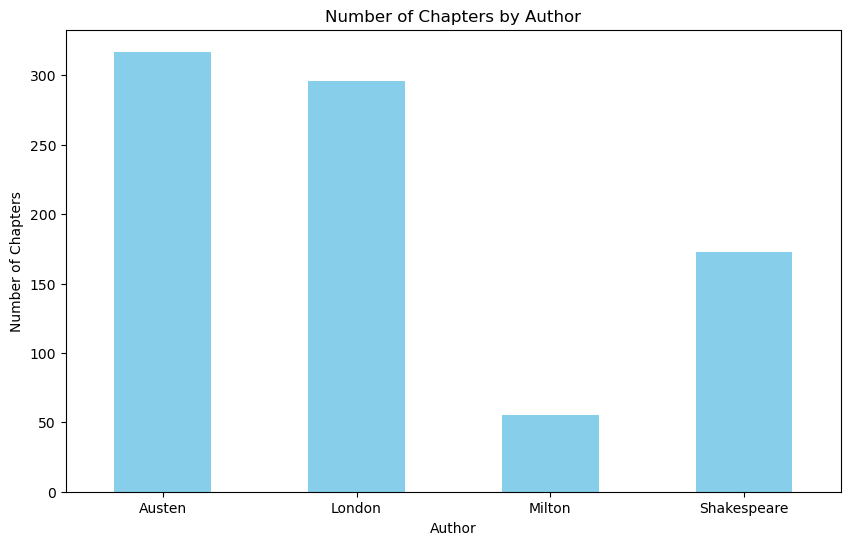

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

author_chapter_counts = aa.groupby('authors')['chapters'].count()

plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
author_chapter_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Chapters by Author')
plt.xlabel('Author')
plt.ylabel('Number of Chapters')
plt.xticks(rotation=0)  # Rotate x-axis labels if needed
plt.show()


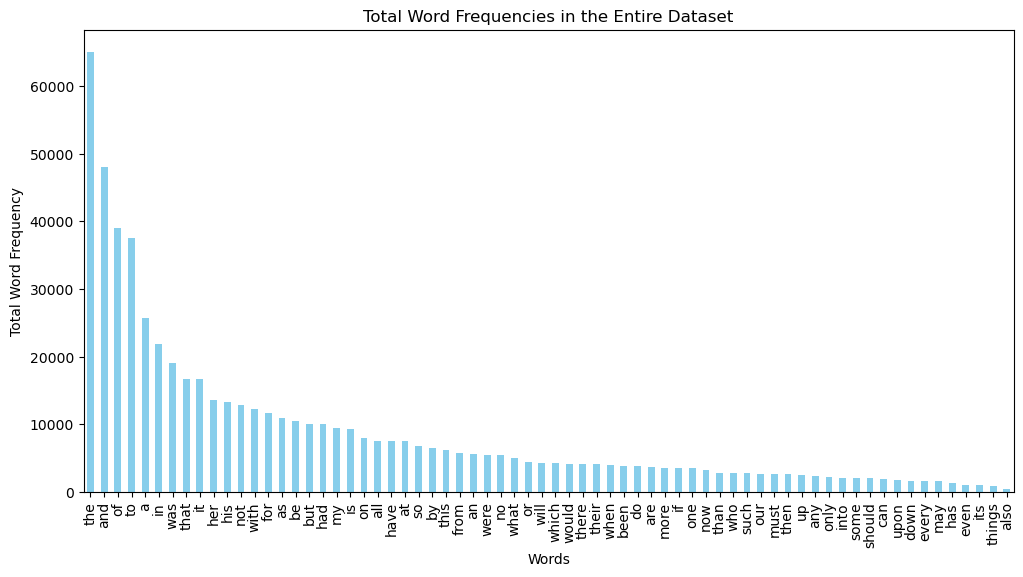

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

total_word_frequencies = aa.iloc[:, 0:68].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
total_word_frequencies.plot(kind='bar', color='skyblue')
plt.title('Total Word Frequencies in the Entire Dataset')
plt.xlabel('Words')
plt.ylabel('Total Word Frequency')
plt.xticks(rotation=90)
plt.show()


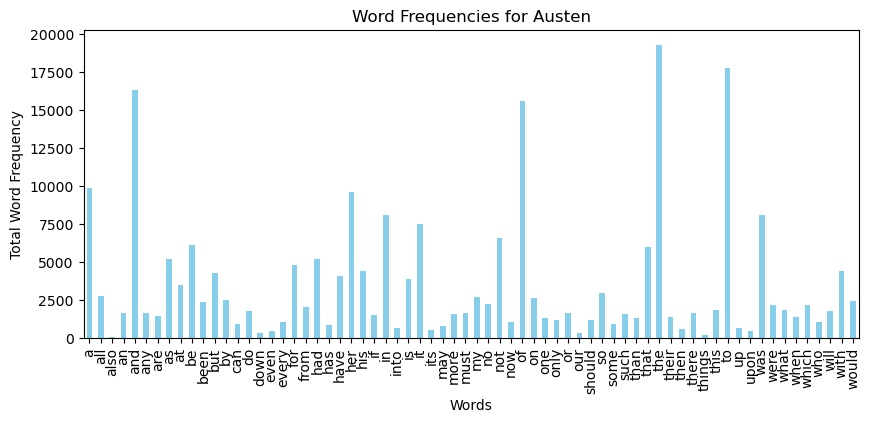

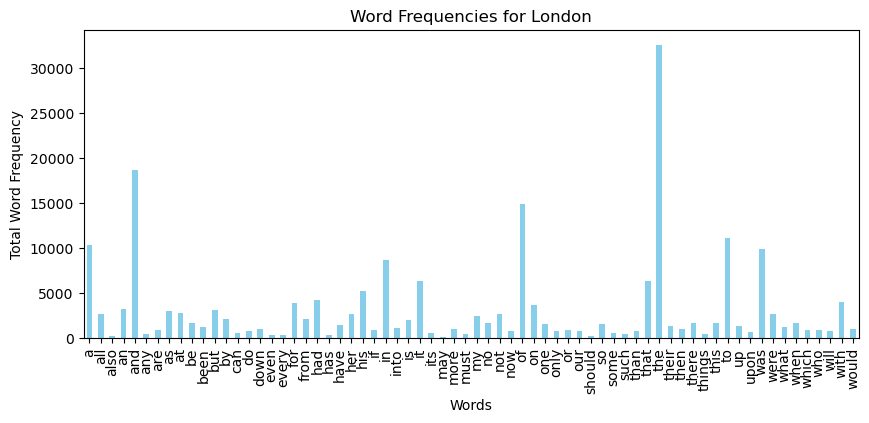

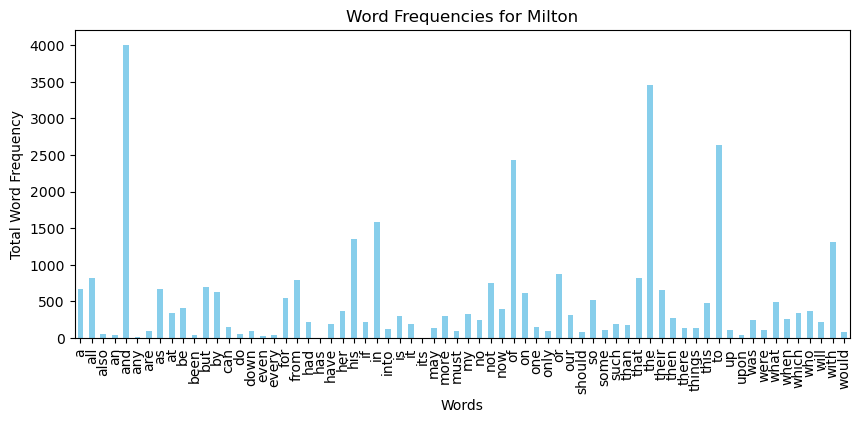

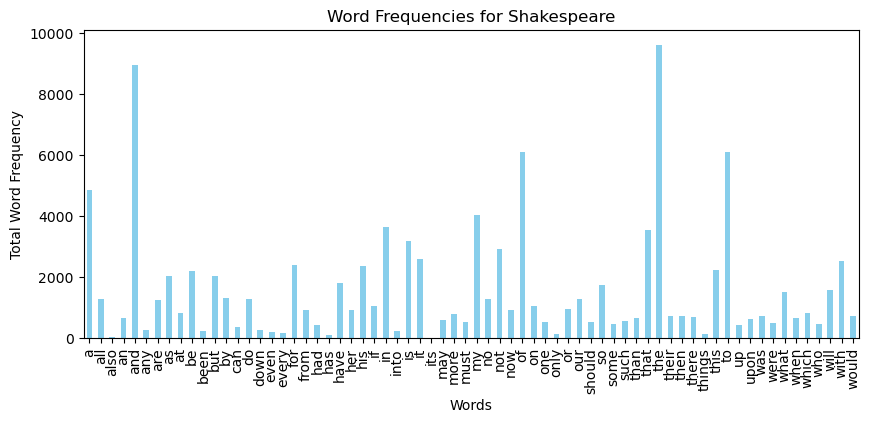

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

grouped_by_author = aa.groupby('authors')

for author, author_data in grouped_by_author:
    author_word_frequencies = author_data.iloc[:, 0:68].sum()
    
    plt.figure(figsize=(10, 4))  # Adjust the figure size as needed
    author_word_frequencies.plot(kind='bar', color='skyblue')
    plt.title(f'Word Frequencies for {author}')
    plt.xlabel('Words')
    plt.ylabel('Total Word Frequency')
    plt.xticks(rotation=90)
    plt.show()


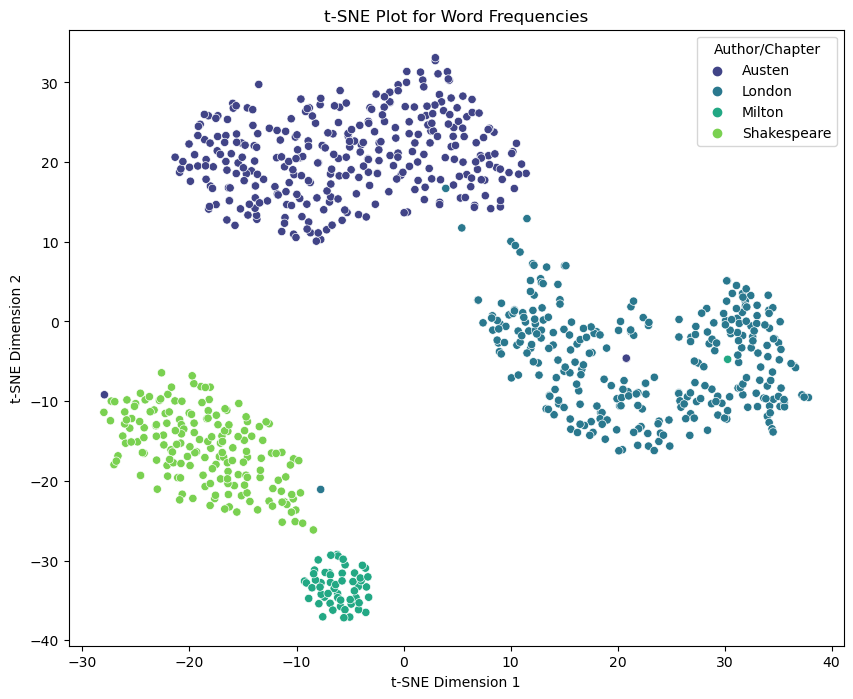

In [5]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

data_for_tsne = aa.iloc[:, 0:68]
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(data_for_tsne)
aa['Color'] = aa['authors']

plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue='Color', data=aa, palette='viridis')
plt.title('t-SNE Plot for Word Frequencies')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Author/Chapter', loc='upper right')
plt.show()


## PCA
## a) Author Text ( PCA )

## 1- AUSTEN

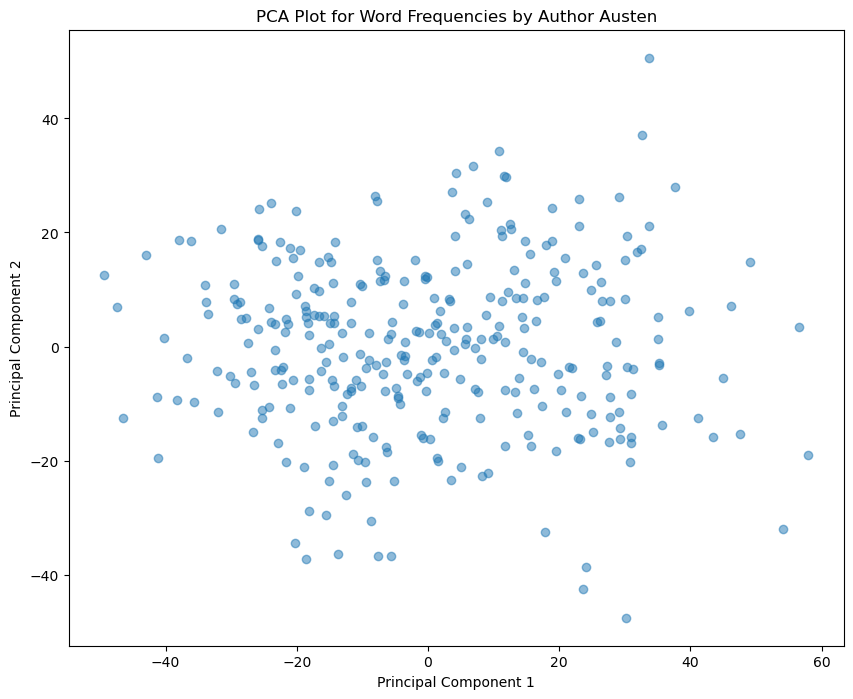

In [7]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

austen_data = aa[aa['authors'] == 'Austen']
data_for_pca = austen_data.iloc[:, 0:68]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_for_pca)

plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title('PCA Plot for Word Frequencies by Author Austen')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


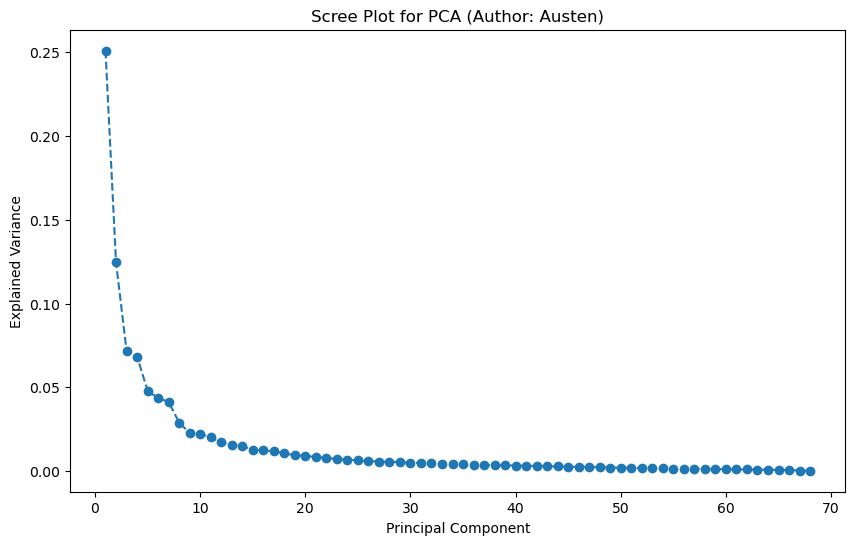

In [9]:
pca = PCA()
pca_result = pca.fit(data_for_pca)

explained_variance = pca_result.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA (Author: Austen)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()


In [10]:
import pandas as pd
from sklearn.decomposition import PCA

austen_data = aa[aa['authors'] == 'Austen']
data_for_pca = austen_data.iloc[:, 0:68]

pca = PCA(n_components=8)
pca_result = pca.fit(data_for_pca)

loadings = pca.components_[:8]
loadings_df = pd.DataFrame(loadings, columns=data_for_pca.columns)

print("PCA Loadings for the First 8 Principal Components (Author: Austen):")
print(loadings_df)


PCA Loadings for the First 8 Principal Components (Author: Austen):
          a       all      also        an       and       any       are  \
0  0.053910  0.020513  0.002699  0.021805  0.291909 -0.027307 -0.084801   
1 -0.194280  0.025629 -0.001828 -0.018885 -0.007782  0.009755 -0.058129   
2 -0.164019 -0.009541  0.004683  0.005756 -0.240768  0.025706 -0.064309   
3 -0.028802 -0.030240  0.000187  0.035713 -0.203291 -0.004531  0.032292   
4  0.532730 -0.006109  0.000201 -0.005621  0.403547  0.017297  0.029858   
5 -0.011935 -0.091087  0.003287 -0.009320 -0.432028  0.011344  0.022886   
6  0.533819 -0.033305 -0.006591  0.006662 -0.195545  0.047994 -0.027363   
7 -0.395302  0.101272 -0.002549  0.036033  0.509772  0.018734 -0.001400   

         as        at        be  ...      upon       was      were      what  \
0  0.015673  0.028289 -0.086021  ... -0.005143  0.268768  0.066594 -0.034202   
1  0.036217 -0.016583 -0.022152  ... -0.004539  0.145965 -0.001140  0.002690   
2  0.031120 -0.0

In [11]:
import pandas as pd
from sklearn.decomposition import PCA

austen_data = aa[aa['authors'] == 'Austen']

data_for_pca = austen_data.iloc[:, 0:68]
pca = PCA(n_components=8)
pca_result = pca.fit(data_for_pca)

loadings = pca.components_[0]
loadings_df = pd.DataFrame({'Word': data_for_pca.columns, 'Loading': loadings})

loadings_df['Abs_Loading'] = abs(loadings_df['Loading'])
loadings_df = loadings_df.sort_values(by='Abs_Loading', ascending=False)

print("Top 10 Most Important Words for PCA Component 1 (Author: Austen):")
print(loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10))

austen10 = loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10)['Word'].tolist()
austen10

Top 10 Most Important Words for PCA Component 1 (Author: Austen):
    Word   Loading  Abs_Loading
50   the  0.562988     0.562988
23   her  0.333083     0.333083
38    of  0.311493     0.311493
4    and  0.291909     0.291909
59   was  0.268768     0.268768
28    is -0.245557     0.245557
34    my -0.197054     0.197054
20   had  0.193247     0.193247
36   not -0.164031     0.164031
22  have -0.138504     0.138504


['the', 'her', 'of', 'and', 'was', 'is', 'my', 'had', 'not', 'have']

## 2- LONDON

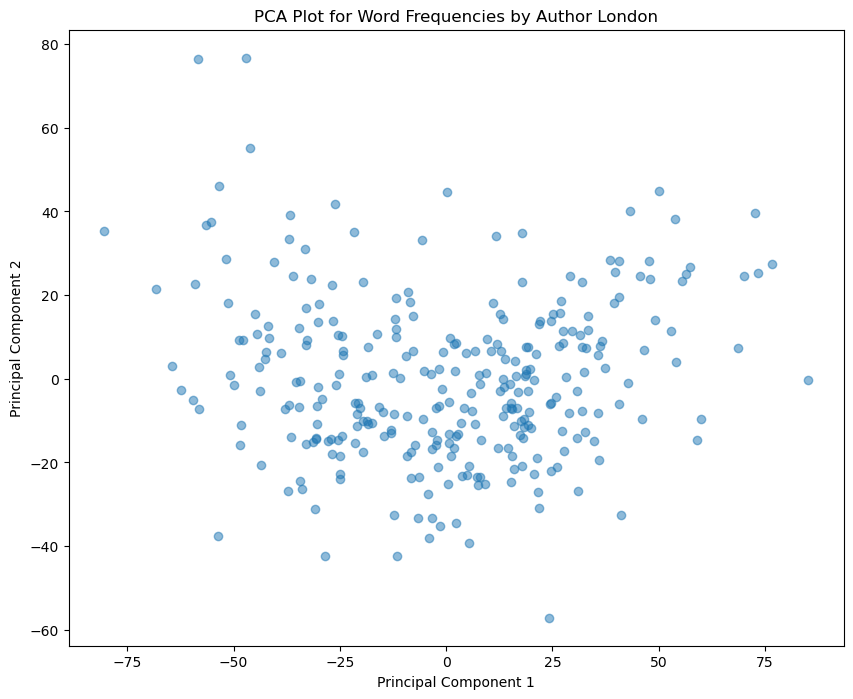

In [12]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

london_data = aa[aa['authors'] == 'London']
data_for_pca = london_data.iloc[:, 0:68]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_for_pca)

plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title('PCA Plot for Word Frequencies by Author London')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


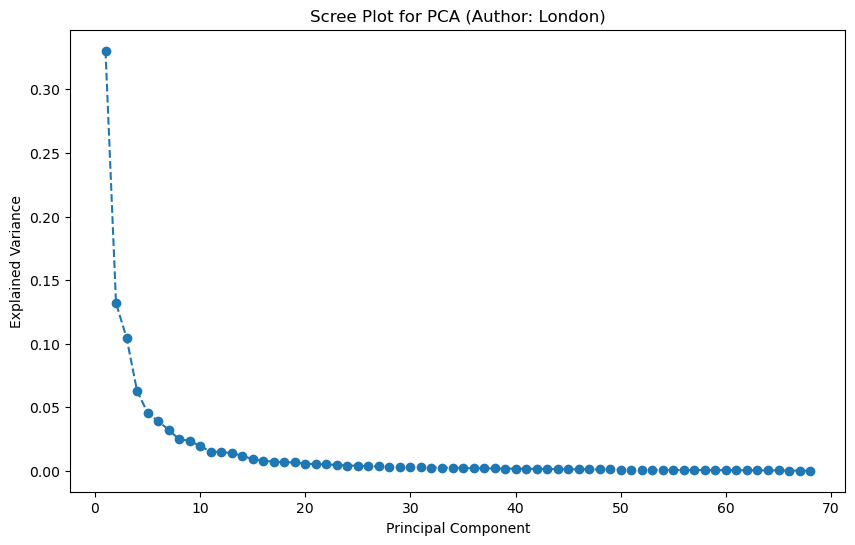

In [13]:
pca = PCA()
pca_result = pca.fit(data_for_pca)

explained_variance = pca_result.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA (Author: London)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()


In [14]:
pca = PCA(n_components=8)
pca_result = pca.fit(data_for_pca)

loadings = pca.components_[:5]
loadings_df = pd.DataFrame(loadings, columns=data_for_pca.columns)

print("PCA Loadings for the First 5 Principal Components (Author: London):")
print(loadings_df)


PCA Loadings for the First 5 Principal Components (Author: London):
          a       all      also        an       and       any       are  \
0 -0.098297 -0.023330  0.009751 -0.269480  0.416982 -0.008964 -0.011951   
1  0.043632  0.014639 -0.008458  0.393575 -0.594049 -0.004419 -0.002298   
2 -0.097371  0.050117  0.003799 -0.135204 -0.070526  0.015490  0.130223   
3  0.011565  0.041957 -0.010832  0.008867  0.495089 -0.000838  0.039847   
4  0.156099  0.051167  0.006105  0.091381  0.018068  0.000745 -0.108455   

         as        at        be  ...      upon       was      were      what  \
0 -0.004668 -0.009322 -0.020778  ...  0.028060  0.143265  0.120473 -0.047288   
1 -0.051748 -0.014882  0.014067  ... -0.023375 -0.166670 -0.018503  0.015415   
2  0.029002 -0.077051  0.064247  ... -0.034310 -0.274249 -0.001194  0.047193   
3  0.005248 -0.015709  0.023611  ... -0.026364 -0.526320  0.006373  0.008884   
4 -0.019923 -0.043022 -0.052898  ... -0.018954  0.417639  0.073096 -0.023946   



In [15]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pca_result = pca.fit(data_for_pca)

loadings = pca.components_[0]
loadings_df = pd.DataFrame({'Word': data_for_pca.columns, 'Loading': loadings})

loadings_df['Abs_Loading'] = abs(loadings_df['Loading'])

loadings_df = loadings_df.sort_values(by='Abs_Loading', ascending=False)
print("Top 10 Most Important Words for PCA Component 1 (Author: Austen):")
print(loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10))

london10 = loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10)['Word'].tolist()
london10

Top 10 Most Important Words for PCA Component 1 (Author: Austen):
    Word   Loading  Abs_Loading
50   the  0.719294     0.719294
4    and  0.416982     0.416982
38    of  0.361330     0.361330
3     an -0.269480     0.269480
59   was  0.143265     0.143265
26    in  0.123863     0.123863
60  were  0.120473     0.120473
23   her -0.104130     0.104130
0      a -0.098297     0.098297
29    it -0.063499     0.063499


['the', 'and', 'of', 'an', 'was', 'in', 'were', 'her', 'a', 'it']

## 3-  MILTON

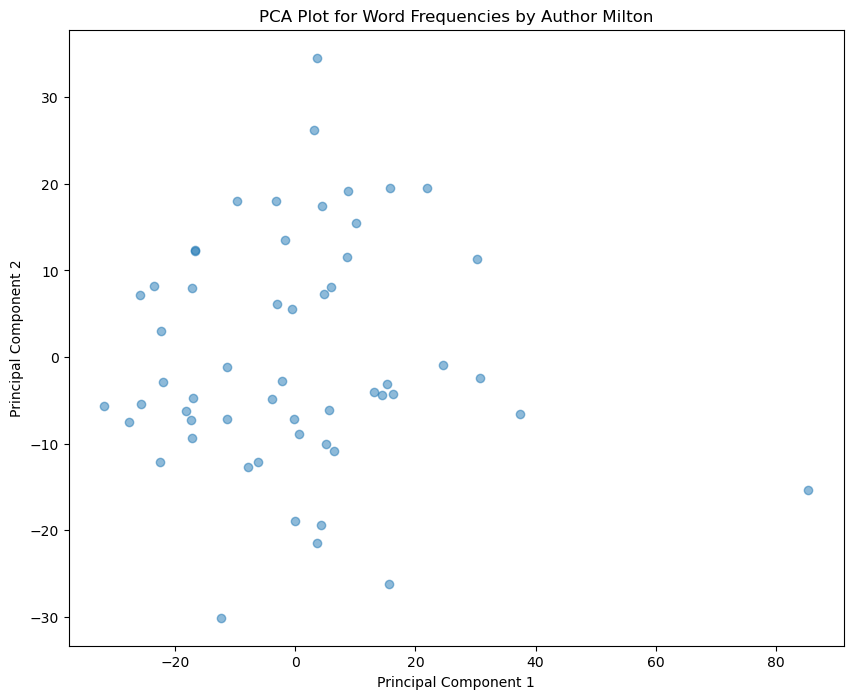

In [16]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

milton_data = aa[aa['authors'] == 'Milton']
data_for_pca = milton_data.iloc[:, 0:68]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_for_pca)

plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title('PCA Plot for Word Frequencies by Author Milton')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


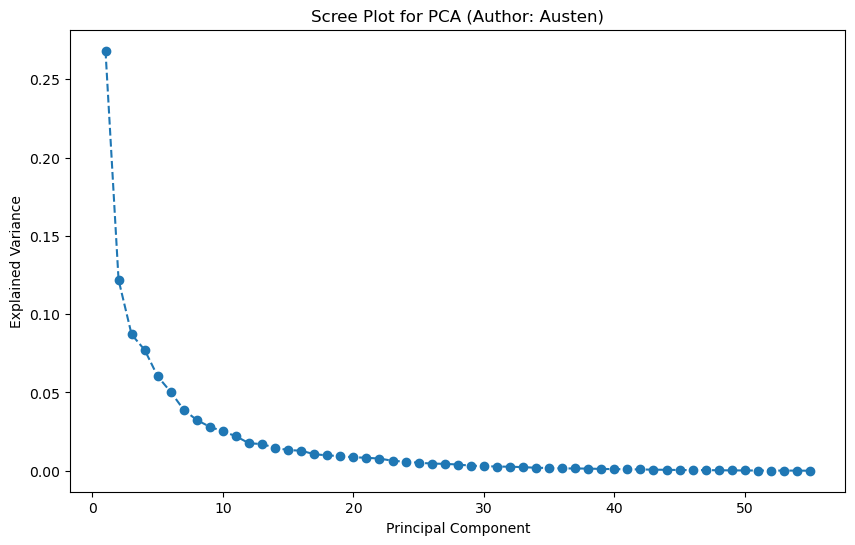

In [17]:
pca = PCA()
pca_result = pca.fit(data_for_pca)

explained_variance = pca_result.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA (Author: Austen)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()


In [18]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pca_result = pca.fit(data_for_pca)

loadings = pca.components_[:5]
loadings_df = pd.DataFrame(loadings, columns=data_for_pca.columns)

print("PCA Loadings for the First 5 Principal Components (Author: Milton):")
print(loadings_df)


PCA Loadings for the First 5 Principal Components (Author: Milton):
          a       all      also        an       and       any       are  \
0  0.123366 -0.012523 -0.001941  0.000741  0.324932 -0.001160 -0.026819   
1  0.041210 -0.043753 -0.009863  0.007423 -0.491077 -0.001015 -0.015258   
2  0.010080 -0.091533 -0.006635 -0.021826 -0.596171  0.011125  0.002129   
3 -0.251466 -0.129378  0.015996  0.015825 -0.160456 -0.002580  0.004113   
4  0.206896  0.204183  0.016433  0.003819  0.192158 -0.013713  0.027437   

         as        at        be  ...      upon       was      were      what  \
0 -0.032577 -0.006444 -0.056835  ...  0.006414  0.048278  0.010224 -0.145140   
1 -0.022915 -0.005032 -0.012846  ...  0.000967 -0.011331 -0.005778 -0.046684   
2  0.129405 -0.013920 -0.086531  ... -0.001258 -0.023480  0.025772 -0.071916   
3  0.035327 -0.029668 -0.005607  ... -0.008023  0.096111 -0.035039  0.037785   
4 -0.030197  0.033155  0.032152  ... -0.004598  0.011333 -0.013511 -0.069711   



In [19]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pca_result = pca.fit(data_for_pca)

loadings = pca.components_[0]
loadings_df = pd.DataFrame({'Word': data_for_pca.columns, 'Loading': loadings})

loadings_df['Abs_Loading'] = abs(loadings_df['Loading'])
loadings_df = loadings_df.sort_values(by='Abs_Loading', ascending=False)

print("Top 10 Most Important Words for PCA Component 1 (Author: Austen):")
print(loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10))

milton10 = loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10)['Word'].tolist()
milton10

Top 10 Most Important Words for PCA Component 1 (Author: Austen):
     Word   Loading  Abs_Loading
50    the  0.754584     0.754584
4     and  0.324932     0.324932
56     to -0.298342     0.298342
51  their  0.228346     0.228346
36    not -0.206529     0.206529
61   what -0.145140     0.145140
0       a  0.123366     0.123366
43    our -0.114709     0.114709
38     of  0.114370     0.114370
66   with  0.105358     0.105358


['the', 'and', 'to', 'their', 'not', 'what', 'a', 'our', 'of', 'with']

## 4- SHAKESPEARE

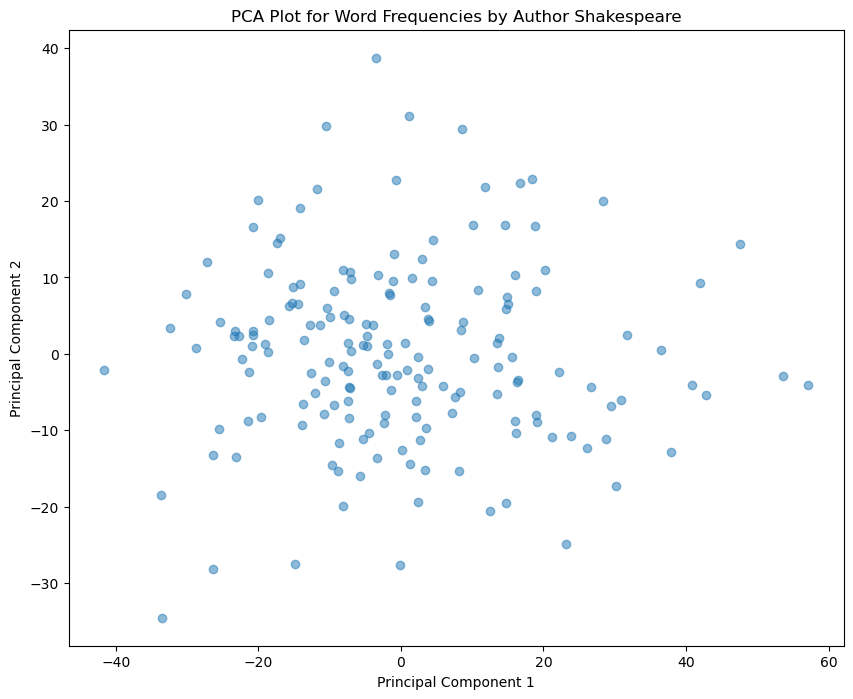

In [21]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


shakespeare_data = aa[aa['authors'] == 'Shakespeare']
data_for_pca = shakespeare_data.iloc[:, 0:68]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_for_pca)

plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title('PCA Plot for Word Frequencies by Author Shakespeare')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


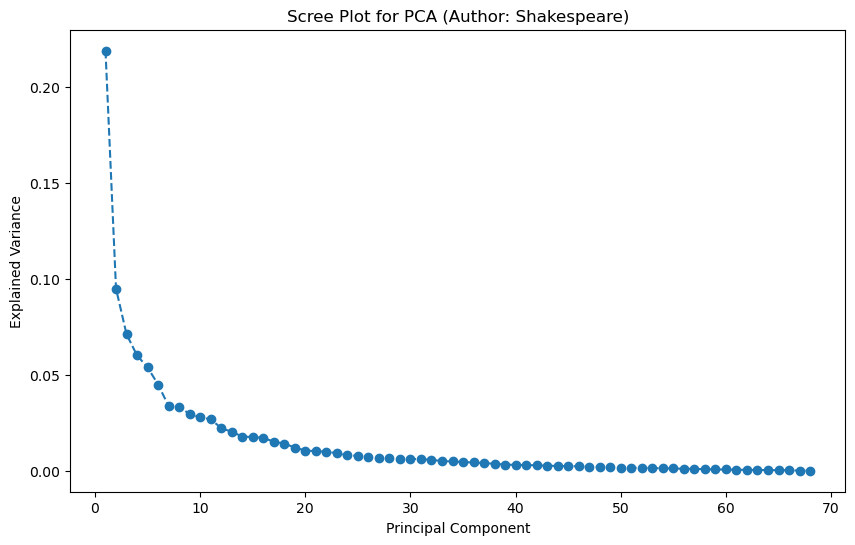

In [22]:
# Initialize and fit the PCA model
pca = PCA()
pca_result = pca.fit(data_for_pca)

explained_variance = pca_result.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA (Author: Shakespeare)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()


In [23]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pca_result = pca.fit(data_for_pca)

loadings = pca.components_[:4]
loadings_df = pd.DataFrame(loadings, columns=data_for_pca.columns)

print("PCA Loadings for the First 4 Principal Components (Author: Shakespeare):")
print(loadings_df)


PCA Loadings for the First 4 Principal Components (Author: Shakespeare):
          a       all      also        an       and       any       are  \
0 -0.092438  0.020922  0.002819 -0.008954  0.418816  0.006087 -0.003084   
1 -0.588089  0.037877 -0.004082 -0.046786  0.196435 -0.019442  0.022820   
2 -0.049354  0.030141  0.000021  0.030721  0.629509  0.016863 -0.002110   
3  0.470030 -0.014558 -0.000138  0.041978 -0.072287  0.025185 -0.078387   

         as        at        be  ...      upon       was      were      what  \
0  0.032046  0.007968 -0.081220  ...  0.013673  0.003405 -0.013226 -0.063429   
1 -0.040898 -0.010667  0.038416  ... -0.022196 -0.051024 -0.050540 -0.023375   
2  0.087115  0.027814  0.025105  ... -0.002769 -0.027121  0.007060 -0.034582   
3  0.165026  0.006822  0.019825  ...  0.009637  0.004694  0.042422 -0.038808   

       when     which       who      will      with     would  
0 -0.006262  0.013171  0.008975 -0.050142  0.074266 -0.025594  
1 -0.018930  0.056830 

In [24]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pca_result = pca.fit(data_for_pca)

loadings = pca.components_[0]
loadings_df = pd.DataFrame({'Word': data_for_pca.columns, 'Loading': loadings})
loadings_df['Abs_Loading'] = abs(loadings_df['Loading'])
loadings_df = loadings_df.sort_values(by='Abs_Loading', ascending=False)

print("Top 10 Most Important Words for PCA Component 1 (Author: Shakespeare):")
print(loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10))

shakespeare10 = loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10)['Word'].tolist()
shakespeare10

Top 10 Most Important Words for PCA Component 1 (Author: Shakespeare):
   Word   Loading  Abs_Loading
50  the  0.651145     0.651145
38   of  0.472814     0.472814
4   and  0.418816     0.418816
34   my -0.164181     0.164181
26   in  0.157820     0.157820
24  his  0.140843     0.140843
36  not -0.134297     0.134297
43  our  0.122932     0.122932
23  her -0.121113     0.121113
0     a -0.092438     0.092438


['the', 'of', 'and', 'my', 'in', 'his', 'not', 'our', 'her', 'a']

## b) Words (PCA)

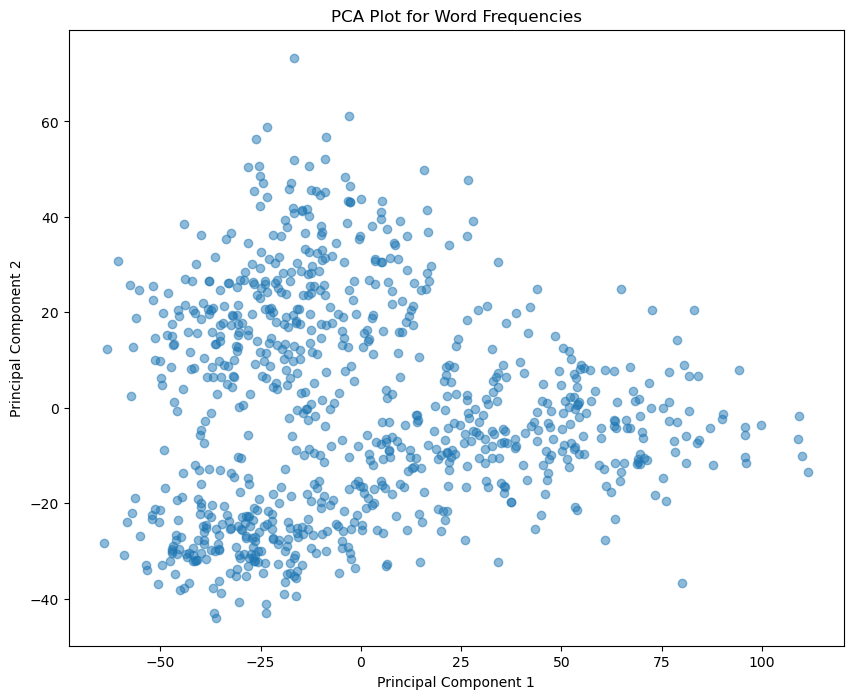

In [28]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_for_pca)

plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title('PCA Plot for Word Frequencies')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


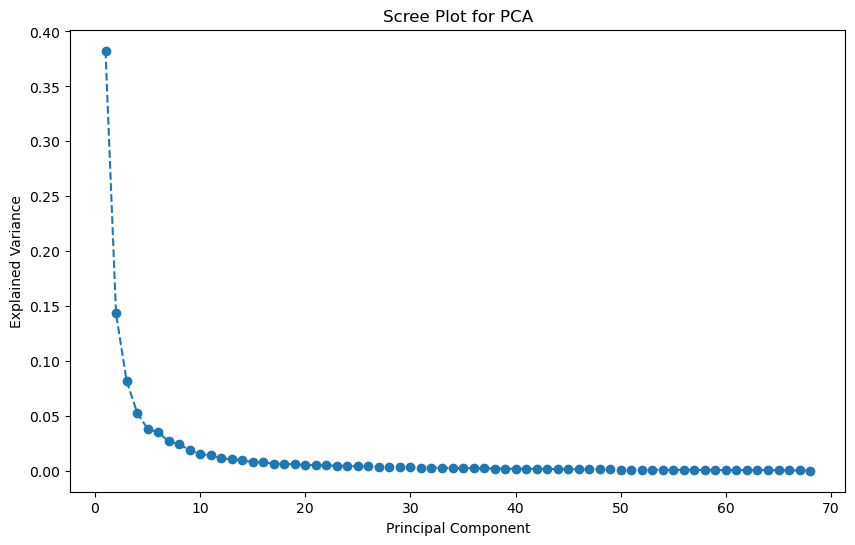

In [32]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca_result = pca.fit(data_for_pca)
explained_variance = pca_result.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()


In [33]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
pca_result = pca.fit_transform(data_for_pca)
loadings = pca.components_
loadings_df = pd.DataFrame(loadings, columns=data_for_pca.columns)

print("Loadings (Coefficients) of Original Features on Principal Components:")
print(loadings_df)


Loadings (Coefficients) of Original Features on Principal Components:
          a       all      also        an       and       any       are  \
0  0.060757  0.002807  0.007796  0.032222  0.224086 -0.022817 -0.040818   
1  0.078955 -0.000370 -0.000513  0.000199 -0.062905  0.063264 -0.050863   
2  0.315738 -0.052338 -0.007879  0.329293 -0.668657  0.015174  0.027803   
3 -0.051762 -0.032006  0.001280 -0.218420 -0.095156  0.037299  0.107722   
4 -0.078991  0.066697 -0.008737  0.189292 -0.013466 -0.022310 -0.004022   

         as        at        be  ...      upon       was      were      what  \
0 -0.044038  0.017619 -0.123229  ...  0.005265  0.254062  0.076597 -0.051974   
1  0.091517  0.095800  0.137829  ... -0.023634  0.392517  0.065716 -0.043611   
2 -0.045605  0.022834  0.016429  ... -0.002473  0.125597 -0.013812  0.001915   
3  0.050057 -0.048786  0.163716  ...  0.003885 -0.157565  0.042186 -0.000379   
4 -0.017402 -0.038985 -0.025385  ... -0.033335 -0.423563 -0.038772  0.014107   

In [34]:
import pandas as pd
from sklearn.decomposition import PCA

loadings = pca.components_[0]
loadings_df = pd.DataFrame({'Word': data_for_pca.columns, 'Loading': loadings})
loadings_df['Abs_Loading'] = abs(loadings_df['Loading'])
loadings_df = loadings_df.sort_values(by='Abs_Loading', ascending=False)

print("Most Important Words for PCA 1:")
print(loadings_df[['Word', 'Loading']].head(10))

words10 = loadings_df[['Word', 'Loading', 'Abs_Loading']].head(10)['Word'].tolist()
words10

Most Important Words for PCA 1:
   Word   Loading
50  the  0.830334
59  was  0.254062
4   and  0.224086
38   of  0.198127
9    be -0.123229
36  not -0.121578
56   to -0.117055
28   is -0.116823
34   my -0.115460
23  her -0.108000


['the', 'was', 'and', 'of', 'be', 'not', 'to', 'is', 'my', 'her']

## SUMMARY OF FIRST 10 WORDS

In [41]:
from IPython.display import display, HTML

authors = ['Austen', 'London', 'Milton', 'Shakespeare', 'All Authors']
top_10_words = [austen10, london10, milton10, shakespeare10, words10]

top_words_df = pd.DataFrame({'Author': authors, 'Top 10 Words': top_10_words})
table_title = "<h1 style='font-weight: bold;'>Top 10 Words for Each Author- with PCA Analysis</h1>"
table_html = top_words_df.to_html(index=False, escape=False, classes='table table-bordered', table_id='top-words-table')

display(HTML(table_title))
display(HTML(table_html))


Author,Top 10 Words
Austen,"[the, her, of, and, was, is, my, had, not, have]"
London,"[the, and, of, an, was, in, were, her, a, it]"
Milton,"[the, and, to, their, not, what, a, our, of, with]"
Shakespeare,"[the, of, and, my, in, his, not, our, her, a]"
All Authors,"[the, was, and, of, be, not, to, is, my, her]"


## c) Texts and Words

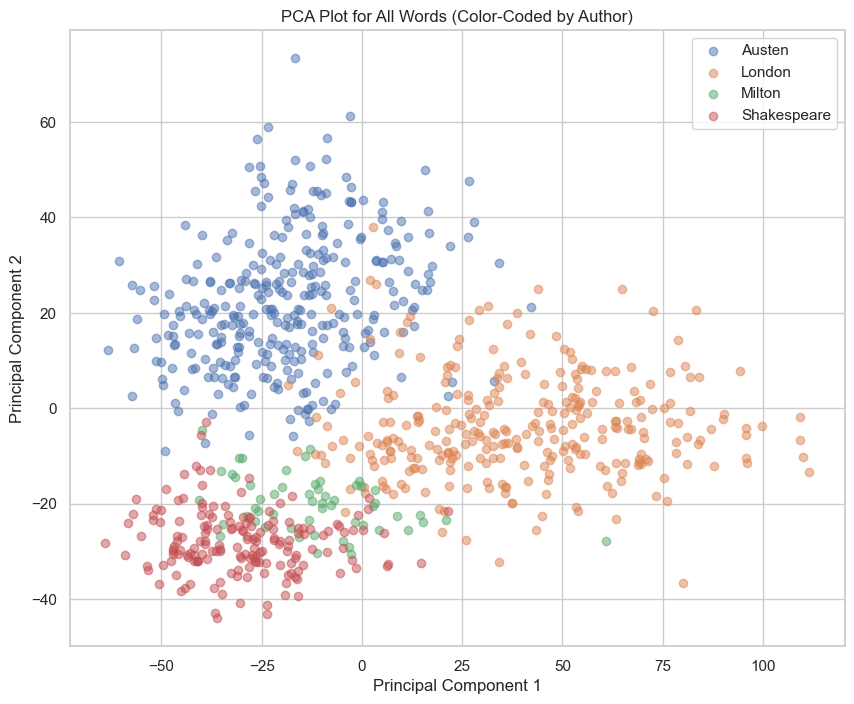

In [42]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_for_pca)

pca_df = pd.DataFrame({'PCA1': pca_result[:, 0], 'PCA2': pca_result[:, 1], 'Author': aa['authors']})

unique_authors = pca_df['Author'].unique()

plt.figure(figsize=(10, 8))
for author in unique_authors:
    author_data = pca_df[pca_df['Author'] == author]
    plt.scatter(author_data['PCA1'], author_data['PCA2'], label=author, alpha=0.5)

plt.title('PCA Plot for All Words (Color-Coded by Author)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


In [62]:
import pandas as pd
from tabulate import tabulate

# Sample data
data = {
    'Author': ['Austen', 'London', 'Milton', 'Shakespeare', 'All Authors'],
    'Words': [
        ['the', 'her', 'of', 'and', 'was', 'is', 'my', 'had', 'not', 'have'],
        ['the', 'and', 'of', 'an', 'was', 'in', 'were', 'her', 'a', 'it'],
        ['the', 'and', 'to', 'their', 'not', 'what', 'a', 'our', 'of', 'with'],
        ['the', 'of', 'and', 'my', 'in', 'his', 'not', 'our', 'her', 'a'],
        ['the', 'was', 'and', 'of', 'be', 'not', 'to', 'is', 'my', 'her']
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Initialize an empty DataFrame for the contingency table
contingency_table = pd.DataFrame(index=df['Author'], columns=df['Author'])

# Fill in the overlap values
for author1 in df['Author']:
    for author2 in df['Author']:
        set1 = set(df[df['Author'] == author1]['Words'].values[0])
        set2 = set(df[df['Author'] == author2]['Words'].values[0])
        overlap = len(set1.intersection(set2))
        contingency_table.at[author1, author2] = overlap

contingency_table_str = tabulate(contingency_table, tablefmt="fancy_grid", headers="keys", showindex=True)

# Define the title
table_title = "Overlap Between Authors' Top Words"

# Combine the title and the formatted table
table_authors = table_title + "\n" + contingency_table_str

# Display the combined string
print(table_authors)


Overlap Between Authors' Top Words
╒═════════════╤══════════╤══════════╤══════════╤═══════════════╤═══════════════╕
│ Author      │   Austen │   London │   Milton │   Shakespeare │   All Authors │
╞═════════════╪══════════╪══════════╪══════════╪═══════════════╪═══════════════╡
│ Austen      │       10 │        5 │        4 │             6 │             8 │
├─────────────┼──────────┼──────────┼──────────┼───────────────┼───────────────┤
│ London      │        5 │       10 │        4 │             6 │             5 │
├─────────────┼──────────┼──────────┼──────────┼───────────────┼───────────────┤
│ Milton      │        4 │        4 │       10 │             6 │             5 │
├─────────────┼──────────┼──────────┼──────────┼───────────────┼───────────────┤
│ Shakespeare │        6 │        6 │        6 │            10 │             6 │
├─────────────┼──────────┼──────────┼──────────┼───────────────┼───────────────┤
│ All Authors │        8 │        5 │        5 │             6 │          

## REFLECTION

### Pre- analysis visualization: Bar plots

I did pre-analsysis as an extra visualization to compare with the visual representations of the data. 

There are 4 authors: Austen, London, Milton and Shakespeare. 

As seen in the above plot:
Chapter number for Austen and London are about 300, 
for Milton 30 and 
for Shakespeare 150. 

Bar graph of the frequencies (above) show the most used words as: 

the     65060

and     47995

of      39045

to      37607

a       25764

in      21923

was     19024

that    16660

it      16615

her     13544

As seen by the bar plots for word frequencies for each author (above), 

we see some words are commonly frequently used for each author, like "the", "to" and "and". but there are differences. 

To have a statistical approach, we can do PCA analysis and look at the loadings of the components. 


### I performed PCA analysis to find most important features for each author and also for all:

PCA aims to find directions (principal components) in the data that capture the most significant variations. Variations arise from the differences in word usage and word frequencies.

### a)Author text

I did the PCA analysis for each aothor seperately and look at the loadings. This gives the most frequent words for each author.  

Below is the table showing "Top 10 Words for Each Author- with PCA Analysis". Most frequent words are different for each author as below, but there are some overlap.That is because the frequencies and distribution of words are different for each aouthor. 
Please see the table for each author frequent words. 

Table shows "the" and "and" as frequent words for each author as we also see at the bar plots in te pre-analysis. PCA and bar plots show similar words, but the bar hight and PCA loadings are not in same order. 

### b) Words

I performed PCA analysis for all authors combined. When I look at the loadings, below table show most frequent words as: [the, was, and, of, be, not, to, is, my, her] for all authors. There are some overlap with each auther frequent words. 

I made a contingency table to show the overlap between authors, please see below. 



### c)  Author and Words

I performed PCA analysis to show all authors and words in two PCA components. Please see the below table. 

The "PCA Plot for All Words" below summarizes the relationship between authors and the words for the PCA components 1 & 2 . 

Each author's data points are color-coded in the plot. The authors with similar writing styles or word usage are grouped closely together. 

While Austen has a more distinct wording style, Milton seems to be overlapping with Shakespeare and London. Austen and London seems to have slight overlap. Shakespeare seems to overlap mostly with Milton. 




Overlap Between Authors' Top Words
╒═════════════╤══════════╤══════════╤══════════╤═══════════════╤═══════════════╕
│ Author      │   Austen │   London │   Milton │   Shakespeare │   All Authors │
╞═════════════╪══════════╪══════════╪══════════╪═══════════════╪═══════════════╡
│ Austen      │       10 │        5 │        4 │             6 │             8 │
├─────────────┼──────────┼──────────┼──────────┼───────────────┼───────────────┤
│ London      │        5 │       10 │        4 │             6 │             5 │
├─────────────┼──────────┼──────────┼──────────┼───────────────┼───────────────┤
│ Milton      │        4 │        4 │       10 │             6 │             5 │
├─────────────┼──────────┼──────────┼──────────┼───────────────┼───────────────┤
│ Shakespeare │        6 │        6 │        6 │            10 │             6 │
├─────────────┼──────────┼──────────┼──────────┼───────────────┼───────────────┤
│ All Authors │        8 │        5 │        5 │             6 │          

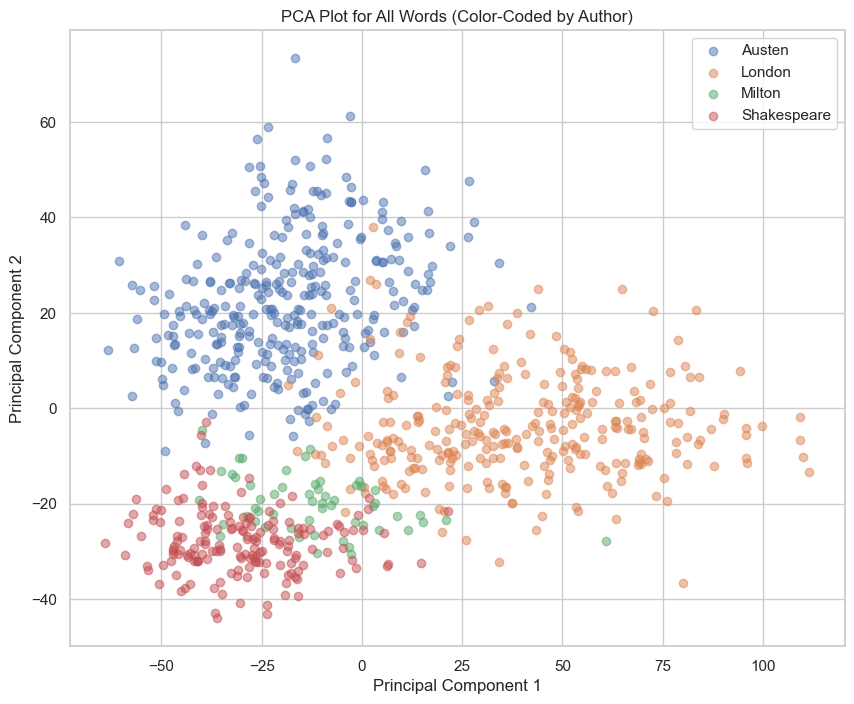

In [64]:
table_html = top_words_df.to_html(index=False, escape=False, classes='table table-bordered', table_id='top-words-table')
display(HTML(table_title))
display(HTML(table_html))

print(table_authors)

plt.figure(figsize=(10, 8))
for author in unique_authors:
    author_data = pca_df[pca_df['Author'] == author]
    plt.scatter(author_data['PCA1'], author_data['PCA2'], label=author, alpha=0.5)

plt.title('PCA Plot for All Words (Color-Coded by Author)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

## CLUSTERING

## K-means

/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


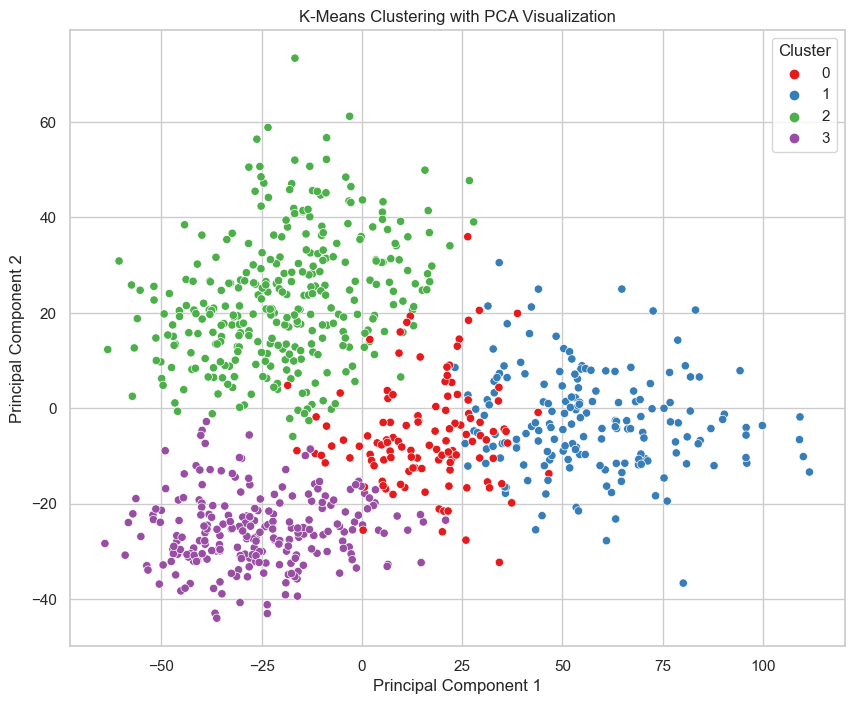

#,Austen,London,Milton,Shakespeare
,,,,
0,3,115,0,2
1,3,172,1,0
2,308,6,0,0
3,3,3,54,171


Adjusted Rand Index (ARI) for K-Means Clustering: 0.7329144864923337


In [65]:
from sklearn.cluster import KMeans

#K-means
data_for_clustering = aa.iloc[:, 0:68]
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(data_for_clustering)
cluster_labels = kmeans.labels_

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue=cluster_labels, palette=sns.color_palette('Set1', n_colors=4), data=pca_df)
plt.title('K-Means Clustering with PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', loc='best')
plt.show()


#TABLE
from IPython.display import display, HTML
contingency_table = pd.crosstab(cluster_labels, aa['authors'], colnames=['#'], rownames=[' '])
table_title = "<h1 style='font-weight: bold;'>Contingency Table for K-Means Clustering</h1>"

display(HTML(table_title))
display(contingency_table)



#ARI:
from sklearn.metrics import adjusted_rand_score

true_author_labels = aa['authors']
ari_kmeans = adjusted_rand_score(true_author_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI) for K-Means Clustering: {ari_kmeans}")



## Hierarchical Clustering

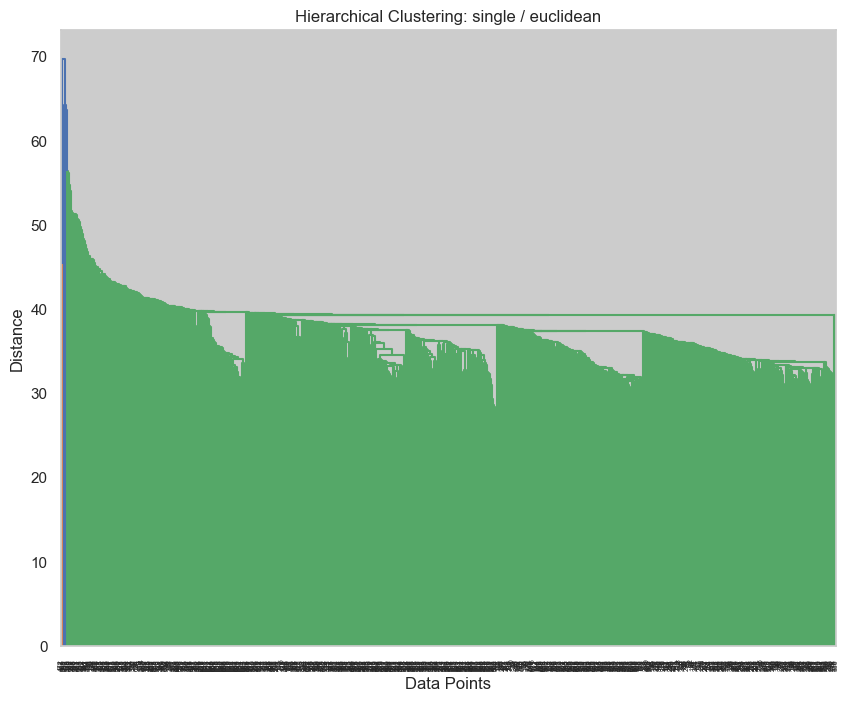

Adjusted Rand Index (ARI) for single, euclidean: -0.001045240855126738


In [70]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

data_for_clustering = aa.iloc[:, 0:68]
true_author_labels = aa['authors']


linkage_method = 'single' #'single' 'complete' 'average' 'ward'
distance_metric = 'euclidean' # 'euclidean' 'cosine'

linkage_matrix = linkage(data_for_clustering, 
                         method=linkage_method, metric=distance_metric)
n_clusters = 4
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')


# Dendogram
fig = plt.figure(figsize=(10, 8))
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title(f'Hierarchical Clustering: single / euclidean')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Calculate the ARI using the chosen threshold
cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
ari_single = adjusted_rand_score(true_author_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI) for single, euclidean: {ari_single}")


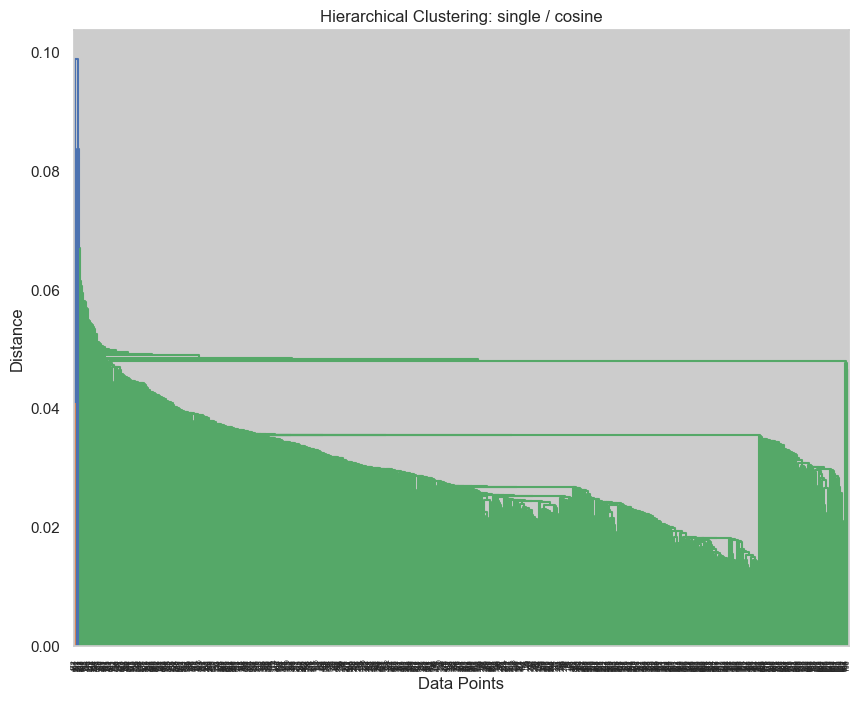

Adjusted Rand Index (ARI) for single, cosine: -5.288698029203867e-05


In [71]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

data_for_clustering = aa.iloc[:, 0:68]
true_author_labels = aa['authors']


linkage_method = 'single' #'single' 'complete' 'average' 'ward'
distance_metric = 'cosine' # 'euclidean' 'cosine'

linkage_matrix = linkage(data_for_clustering, 
                         method=linkage_method, metric=distance_metric)
n_clusters = 4
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

# Dendogram
fig = plt.figure(figsize=(10, 8))
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title(f'Hierarchical Clustering: single / cosine')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Calculate the ARI using the chosen threshold
cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
ari_single2 = adjusted_rand_score(true_author_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI) for single, cosine: {ari_single2}")


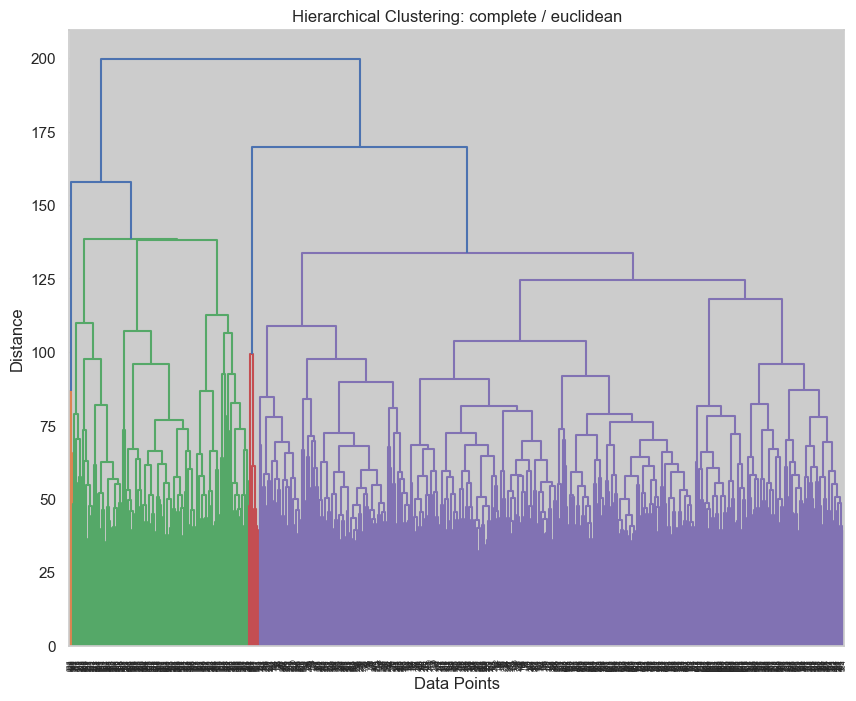

Adjusted Rand Index (ARI) for complete, euclidean: 0.20911865025445078


In [79]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

data_for_clustering = aa.iloc[:, 0:68]
true_author_labels = aa['authors']


linkage_method = 'complete' #'single' 'complete' 'average' 'ward'
distance_metric = 'euclidean' # 'euclidean' 'cosine'

linkage_matrix = linkage(data_for_clustering, 
                         method=linkage_method, metric=distance_metric)
n_clusters = 4
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')


# Dendogram
fig = plt.figure(figsize=(10, 8))
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title(f'Hierarchical Clustering: complete / euclidean')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Calculate the ARI using the chosen threshold
cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
ari_complete = adjusted_rand_score(true_author_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI) for complete, euclidean: {ari_complete}")


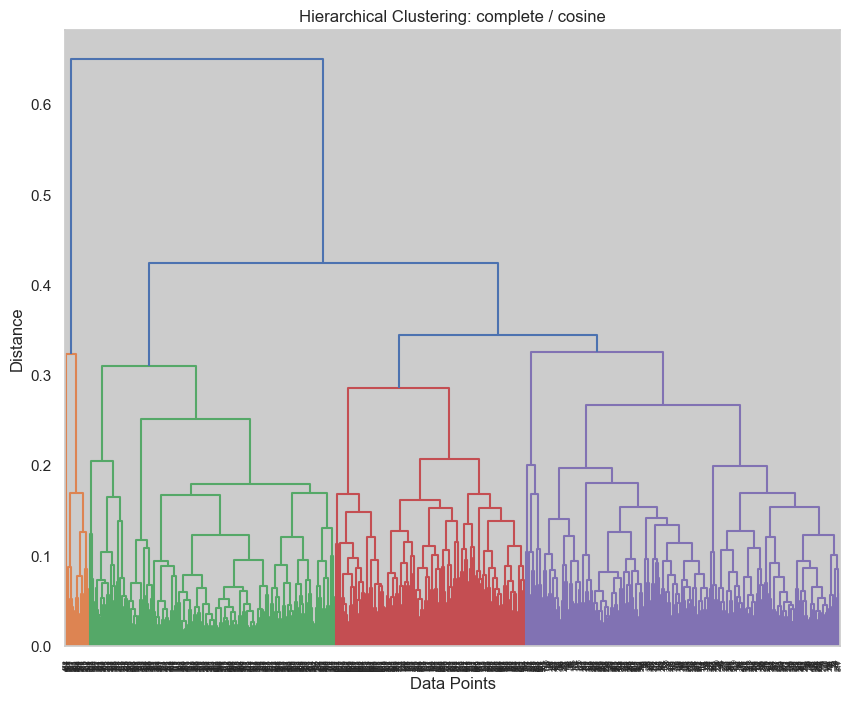

Adjusted Rand Index (ARI) for complete, cosine: 0.46834400988647856


In [80]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

data_for_clustering = aa.iloc[:, 0:68]
true_author_labels = aa['authors']

linkage_method = 'complete' #'single' 'complete' 'average' 'ward'
distance_metric = 'cosine' # 'euclidean' 'cosine'


linkage_matrix = linkage(data_for_clustering, 
                         method=linkage_method, metric=distance_metric)
n_clusters = 4
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')


# Dendogram
fig = plt.figure(figsize=(10, 8))
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title(f'Hierarchical Clustering: complete / cosine')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Calculate the ARI using the chosen threshold
cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
ari_complete2 = adjusted_rand_score(true_author_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI) for complete, cosine: {ari_complete2}")


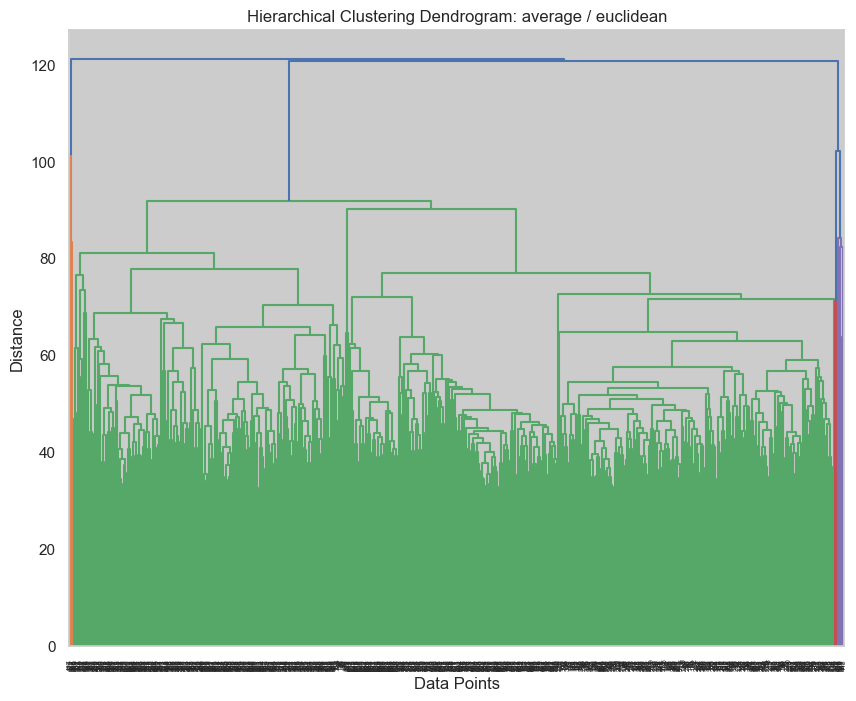

Adjusted Rand Index (ARI) for average, euclidean: -0.0014183666741079326


In [81]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

data_for_clustering = aa.iloc[:, 0:68]
true_author_labels = aa['authors']


linkage_method = 'average' #'single' 'complete' 'average' 'ward'
distance_metric = 'euclidean' # 'euclidean' 'cosine'

linkage_matrix = linkage(data_for_clustering, 
                         method=linkage_method, metric=distance_metric)
n_clusters = 4
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')



# Dendogram
fig = plt.figure(figsize=(10, 8))
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title(f'Hierarchical Clustering Dendrogram: average / euclidean')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Calculate the ARI using the chosen threshold
cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
ari_average = adjusted_rand_score(true_author_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI) for average, euclidean: {ari_average}")


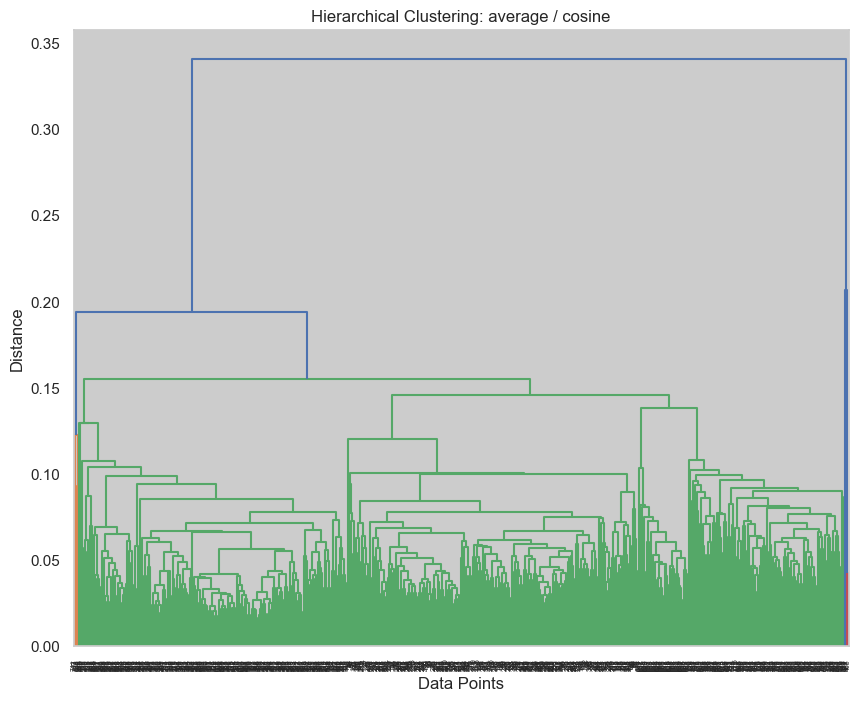

Adjusted Rand Index (ARI) for average, cosine: -0.001045240855126738


In [82]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

data_for_clustering = aa.iloc[:, 0:68]
true_author_labels = aa['authors']


linkage_method = 'average' #'single' 'complete' 'average' 'ward'
distance_metric = 'cosine' # 'euclidean' 'cosine'

linkage_matrix = linkage(data_for_clustering, 
                         method=linkage_method, metric=distance_metric)
n_clusters = 4
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')



# Dendogram
fig = plt.figure(figsize=(10, 8))
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title(f'Hierarchical Clustering: average / cosine')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Calculate the ARI using the chosen threshold
cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
ari_average2 = adjusted_rand_score(true_author_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI) for average, cosine: {ari_average2}")


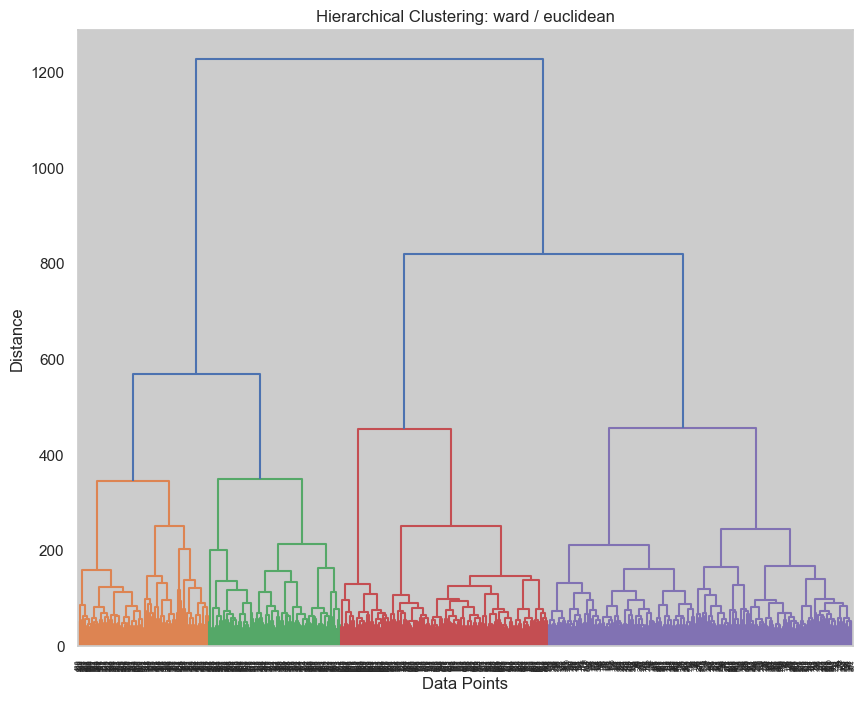

Adjusted Rand Index (ARI) for ward, euclidean: 0.8499180248787804


In [83]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

data_for_clustering = aa.iloc[:, 0:68]
true_author_labels = aa['authors']


linkage_method = 'ward' #'single' 'complete' 'average' 'ward'
distance_metric = 'euclidean' # 'euclidean' 'cosine'

linkage_matrix = linkage(data_for_clustering, 
                         method=linkage_method, metric=distance_metric)
n_clusters = 4
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')



# Dendogram
fig = plt.figure(figsize=(10, 8))
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title(f'Hierarchical Clustering: ward / euclidean')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Calculate the ARI using the chosen threshold
cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
ari_ward = adjusted_rand_score(true_author_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI) for ward, euclidean: {ari_ward}")


## DImentional reduction with PCA


Adjusted Rand Index (ARI) for Hierarchical Clustering with PCA: 0.7021572329995143


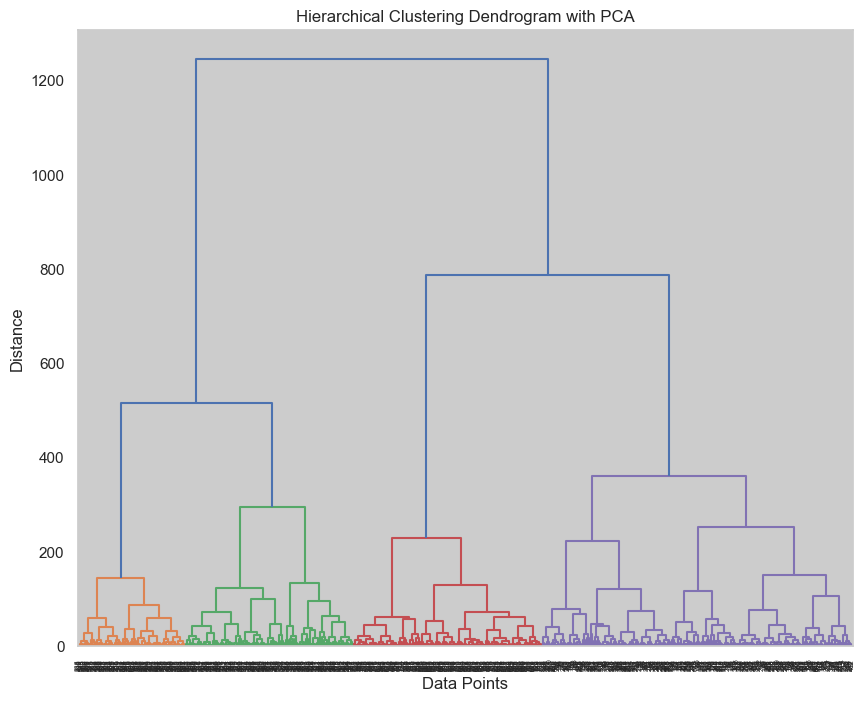

In [84]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score


data_for_clustering = aa.iloc[:, 0:68]  # Select the relevant columns
n_components = 2  # You can choose the number of components
pca = PCA(n_components=n_components)
pca_data = pca.fit_transform(data_for_clustering)

linkage_method = 'ward'
linkage_matrix = linkage(pca_data, method=linkage_method)
n_clusters = 4

cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

true_author_labels = aa['authors']
ari_pca = adjusted_rand_score(true_author_labels, cluster_labels)

print(f"Adjusted Rand Index (ARI) for Hierarchical Clustering with PCA: {ari_pca}")

# Plot the hierarchical clustering dendrogram
fig = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor('white')
threshold = linkage_matrix[-(n_clusters - 1), 2]  # The distance value for the third split
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title('Hierarchical Clustering Dendrogram with PCA')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()



## DImentional reduction with t_SNE

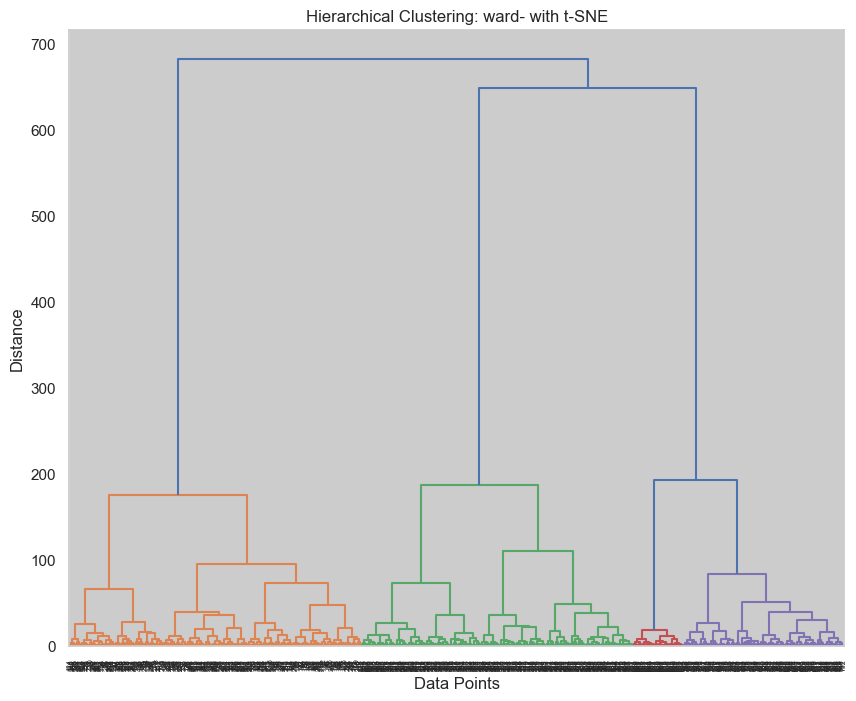

Adjusted Rand Index (ARI) for Hierarchical Clustering with t-SNE: 0.9713925403717748


In [85]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

# t-SNE
data_for_clustering = aa.iloc[:, 0:68]  # Select the relevant columns
tsne = TSNE(n_components=2)  # You can choose the number of components
tsne_data = tsne.fit_transform(data_for_clustering)

linkage_method = 'ward'
linkage_matrix = linkage(tsne_data, method=linkage_method)
n_clusters = 4

cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
true_author_labels = aa['authors']

ari_tsne= adjusted_rand_score(true_author_labels, cluster_labels)

# Dendogram
fig = plt.figure(figsize=(10, 8))
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix, orientation='top', color_threshold=threshold)
plt.title(f'Hierarchical Clustering: ward- with t-SNE')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Print the ARI score
print(f"Adjusted Rand Index (ARI) for Hierarchical Clustering with t-SNE: {ari_tsne}")

In [92]:
from IPython.display import display, HTML
import pandas as pd
ari_scores = {
    'linkeage: single, distance: euclidean': ari_single,
    'linkeage: single, distance: cosine': ari_single2,
    'linkeage: average, distance: euclidean': ari_average,
    'linkeage: average, distance: cosine': ari_average2,
    'linkeage: complete, distance: euclidean': ari_complete,
    'linkeage: complete, distance: cosine': ari_complete2,
    'linkeage: ward_euclidean': ari_ward,
    'linkeage: ward with PCA': ari_pca,
    'linkeage: ward with tSNE': ari_tsne,
    'k-means clustering':ari_kmeans}

ari_df = pd.DataFrame.from_dict(ari_scores, orient='index', columns=['ARI'])
table_title = "<h1 style='font-weight: bold;'>ARI Scores for Different Methods</h1>"
display(HTML(table_title))
display(ari_df)


,ARI
"linkeage: single, distance: euclidean",-0.001045
"linkeage: single, distance: cosine",-0.000053
"linkeage: average, distance: euclidean",-0.001418
"linkeage: average, distance: cosine",-0.001045
"linkeage: complete, distance: euclidean",0.209119
"linkeage: complete, distance: cosine",0.468344
linkeage: ward_euclidean,0.849918
linkeage: ward with PCA,0.702157
linkeage: ward with tSNE,0.971393
k-means clustering,0.732914


## REFLECTION:

I used different compositions of linkages and distances using 
linkages: 'single' 'complete' 'average' 'ward'
and distances: 'euclidean' 'cosine'

Depending on the methods the strucrure of the dendogram and clustering change dramatically. 

### Linkeage "single" and "average"
For single and average, with either cosine or euclidean gives poor classification and visualization. This is reflected in the ARI scores as shown in above table. 

### Linkeage "complete"
Linkeage "complete" classifies groups better than single and average, as seen in dendograms and below table. Distance "cosine" gives better results for complete. 

### Linkeage "ward"
Linkeage "ward" gives best classification with ARI score of 0.85.

I used PCA and tSNE dimensionality reduction techniques with linkeage "ward".

tSNE with hierarchical clustering linkeage ward gives the best classification of 0.97 ARI. Plese refer to above table


In [94]:
display(ari_df)


,ARI
"linkeage: single, distance: euclidean",-0.001045
"linkeage: single, distance: cosine",-0.000053
"linkeage: average, distance: euclidean",-0.001418
"linkeage: average, distance: cosine",-0.001045
"linkeage: complete, distance: euclidean",0.209119
"linkeage: complete, distance: cosine",0.468344
linkeage: ward_euclidean,0.849918
linkeage: ward with PCA,0.702157
linkeage: ward with tSNE,0.971393
k-means clustering,0.732914


## PCA ON WORDS

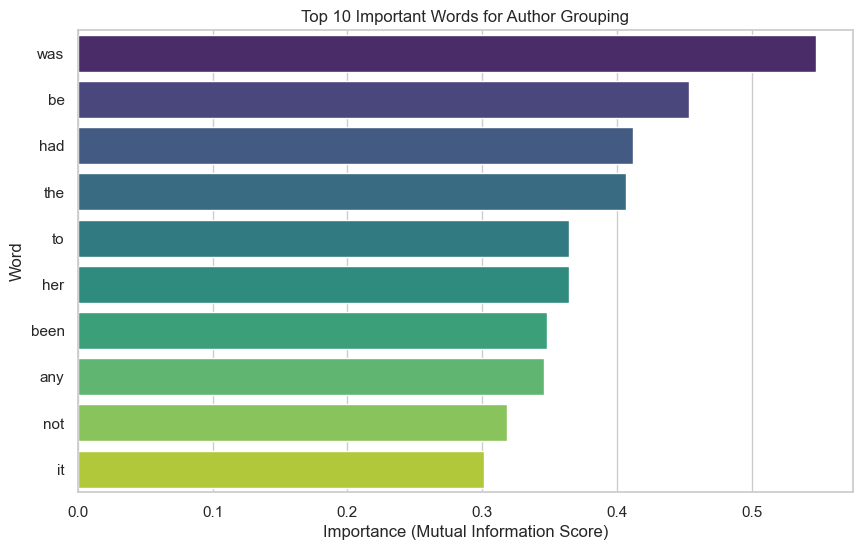

In [295]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd
import seaborn as sns

# Feature 
k_best = SelectKBest(score_func=mutual_info_classif, k=10)
selected_features = k_best.fit_transform(aa.iloc[:, 0:68], aa['authors'])

# Visualize Word Importance
selected_feature_indices = k_best.get_support(indices=True)
selected_words = aa.columns[0:68][selected_feature_indices]
selected_word_importance = k_best.scores_[selected_feature_indices]
word_importance_df = pd.DataFrame({'Word': selected_words, 'Importance': selected_word_importance})
word_importance_df = word_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Word', data=word_importance_df, palette='viridis')
plt.title('Top 10 Important Words for Author Grouping')
plt.xlabel('Importance (Mutual Information Score)')
plt.ylabel('Word')
plt.show()


## PCA ON WORDS

## PCA for all words

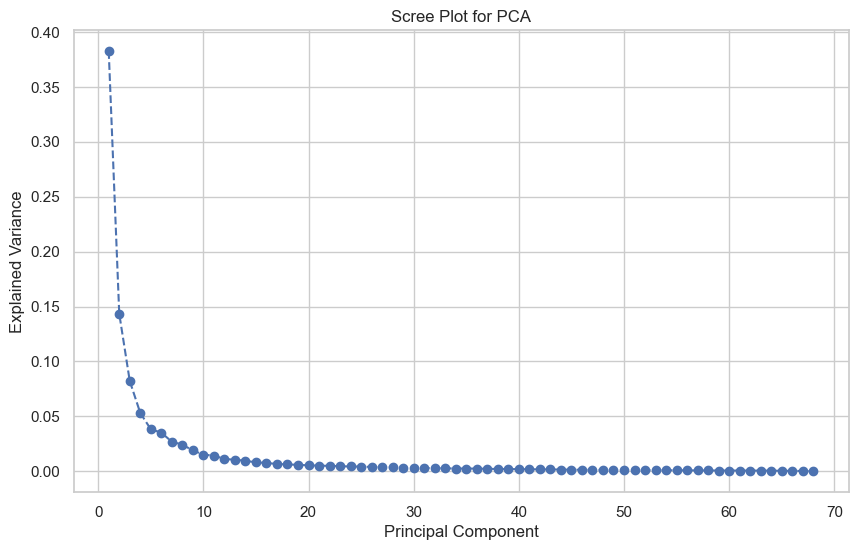

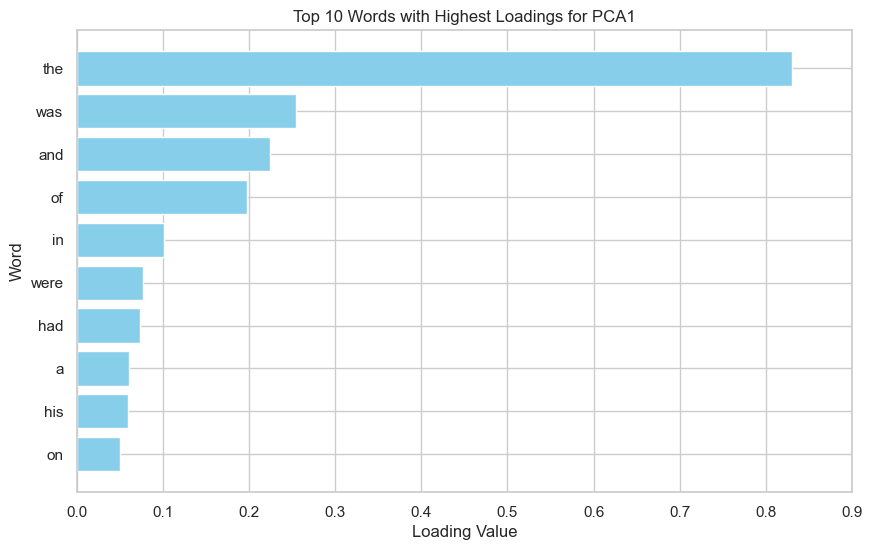

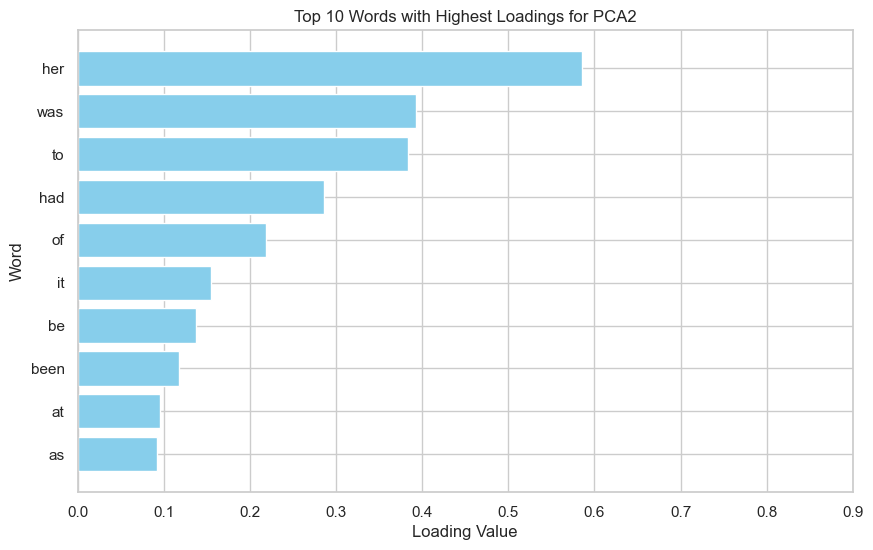

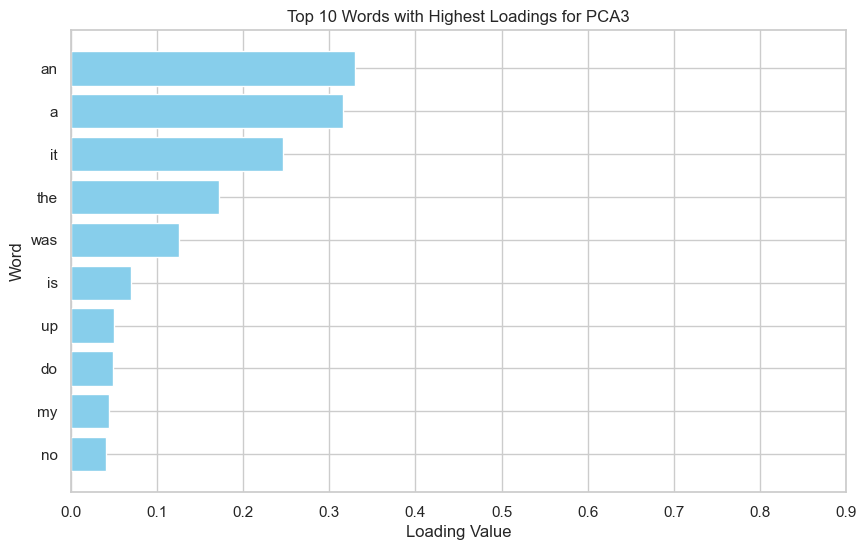

In [116]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data_for_pca = aa.iloc[:, 0:68]
pca = PCA()
pca_result = pca.fit(data_for_pca)
explained_variance = pca_result.explained_variance_ratio_
# scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()

#PCA1
loadings = pca.components_
pca1_loadings = loadings[0]
words = data_for_pca.columns
sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]
# Select the top 10 words 
top_10_words = top_words[:10]
# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title('Top 10 Words with Highest Loadings for PCA1')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()

#PCA2
pca1_loadings = loadings[1]
words = data_for_pca.columns
sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]
# Select the top 10 words
top_10_words = top_words[:10]
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title('Top 10 Words with Highest Loadings for PCA2')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis()  
plt.xlim(0, 0.9)
plt.show()

#PCA3
pca1_loadings = loadings[2]
words = data_for_pca.columns
sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]
# Select the top 10 words 
top_10_words = top_words[:10]
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title('Top 10 Words with Highest Loadings for PCA3')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()


## Austen

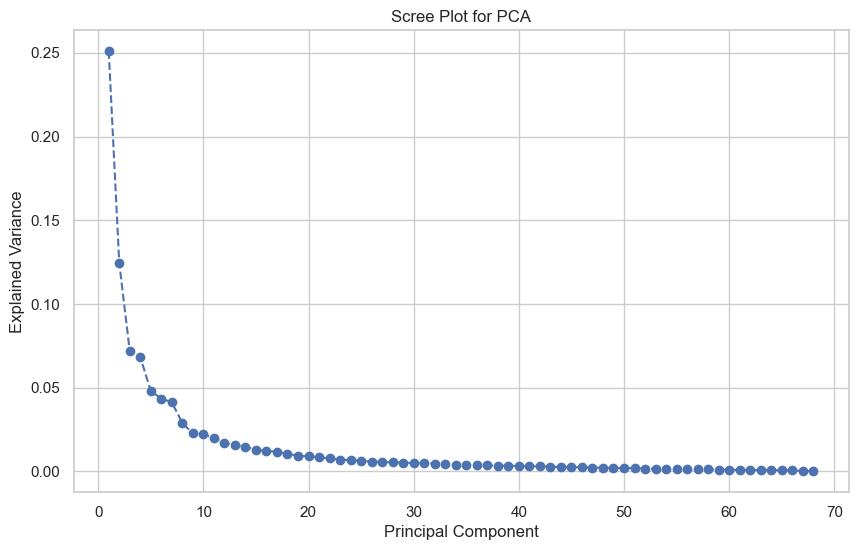

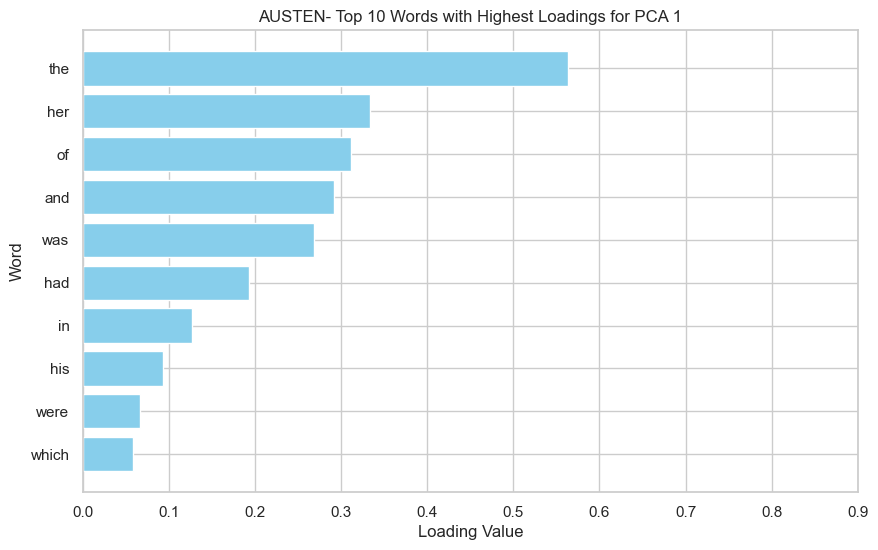

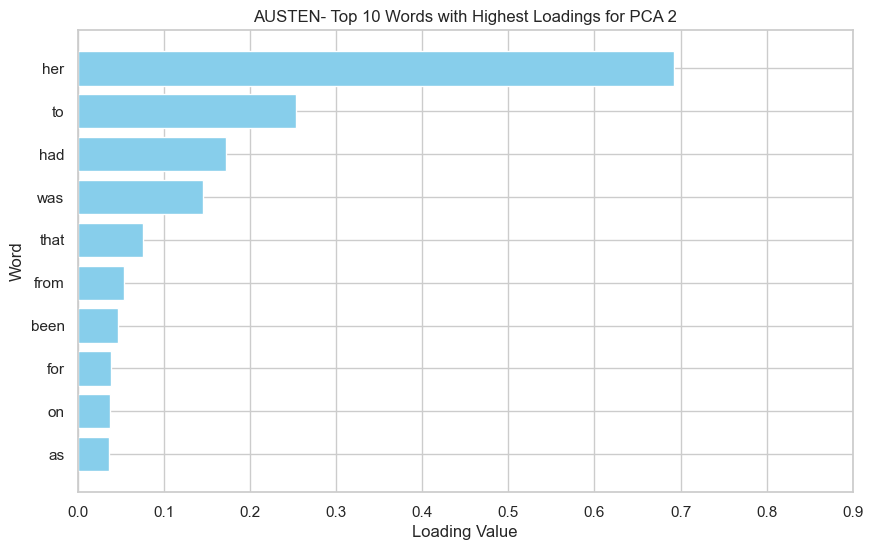

In [117]:
#LONDON
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

london_data = aa[aa['authors'] == 'Austen']
data_for_pca1 = london_data.iloc[:, 0:68]

pca = PCA()
pca_result = pca.fit(data_for_pca1)
explained_variance = pca_result.explained_variance_ratio_

# scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()



#PCA 1
loadings = pca.components_
pca1_loadings = loadings[0]
words = data_for_pca.columns

sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]

# Select the top 10 words 
top_10_words = top_words[:10]
A1=top_10_words
# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title('AUSTEN- Top 10 Words with Highest Loadings for PCA 1')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()



#PCA 2
loadings = pca.components_
pca1_loadings = loadings[1]
words = data_for_pca.columns

sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]

# Select the top 10 words 
top_10_words = top_words[:10]
A2=top_10_words
# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title('AUSTEN- Top 10 Words with Highest Loadings for PCA 2')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()

## London

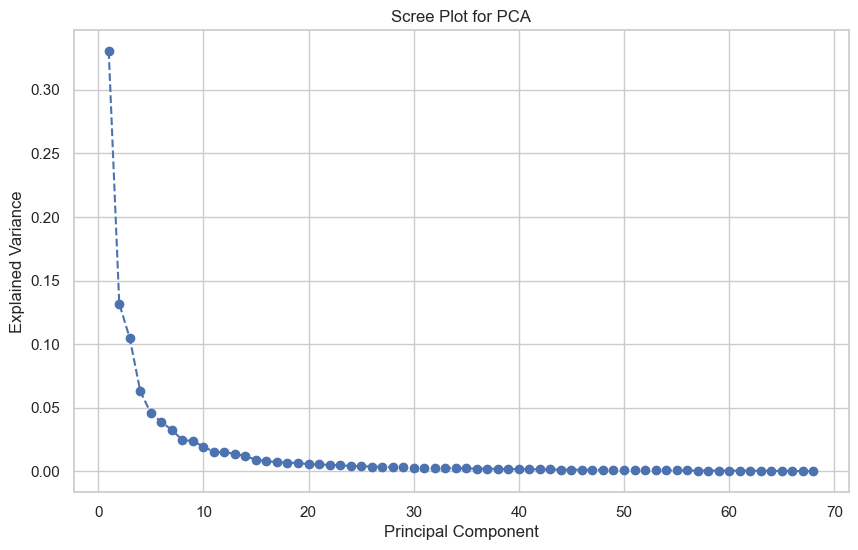

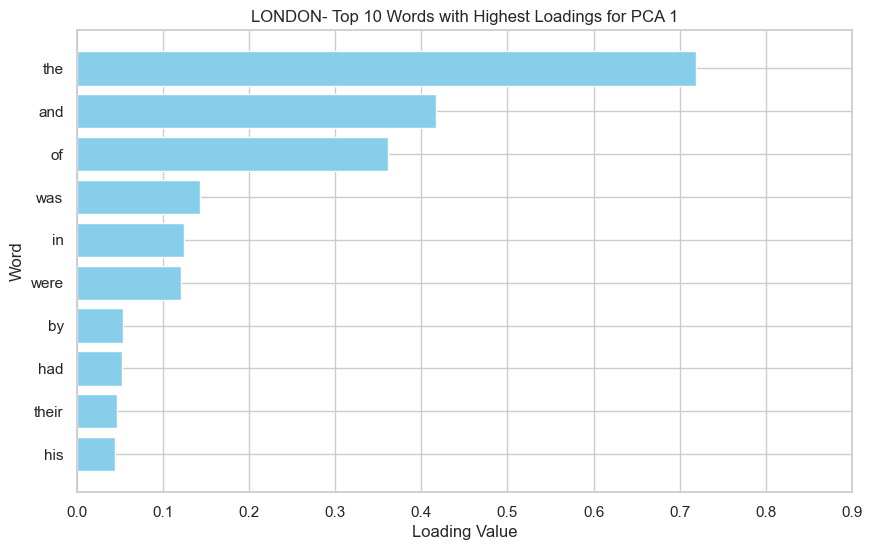

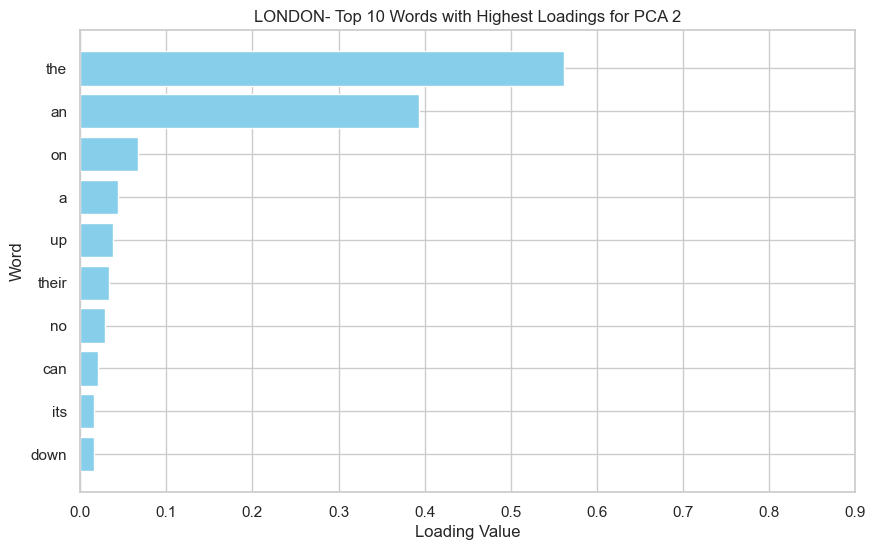

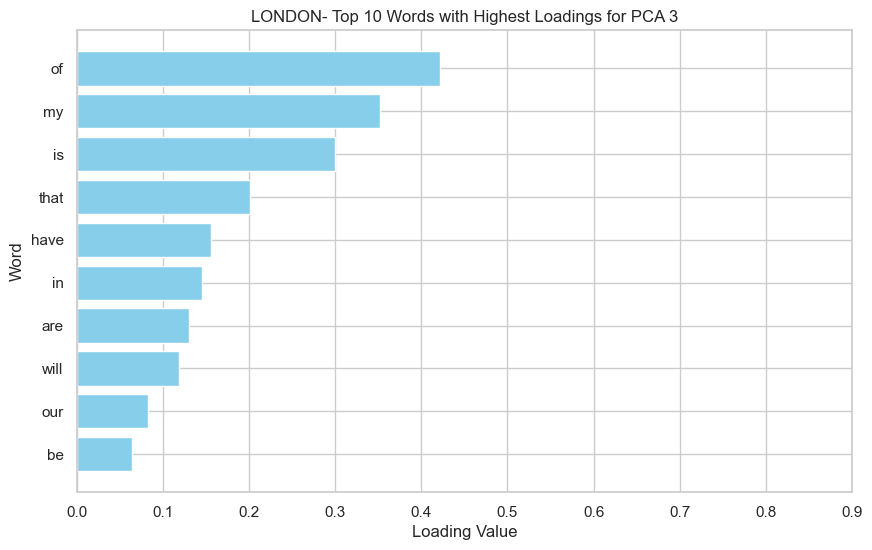

In [118]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

london_data = aa[aa['authors'] == 'London']
data_for_pca1 = london_data.iloc[:, 0:68]
pca = PCA()
pca_result = pca.fit(data_for_pca1)
explained_variance = pca_result.explained_variance_ratio_
# scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()

#PCA 1
loadings = pca.components_
pca1_loadings = loadings[0]
words = data_for_pca.columns
sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]
# Select the top 10 words 
top_10_words = top_words[:10]
L1=top_10_words
# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title('LONDON- Top 10 Words with Highest Loadings for PCA 1')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()

#PCA 2
loadings = pca.components_
pca1_loadings = loadings[1]
words = data_for_pca.columns
sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]
# Select the top 10 words 
top_10_words = top_words[:10]
L2=top_10_words

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title('LONDON- Top 10 Words with Highest Loadings for PCA 2')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()
#PCA 3
loadings = pca.components_
pca1_loadings = loadings[2]
words = data_for_pca.columns

sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]

# Select the top 10 words 
top_10_words = top_words[:10]
L3=top_10_words

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title('LONDON- Top 10 Words with Highest Loadings for PCA 3')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()

## MILTON

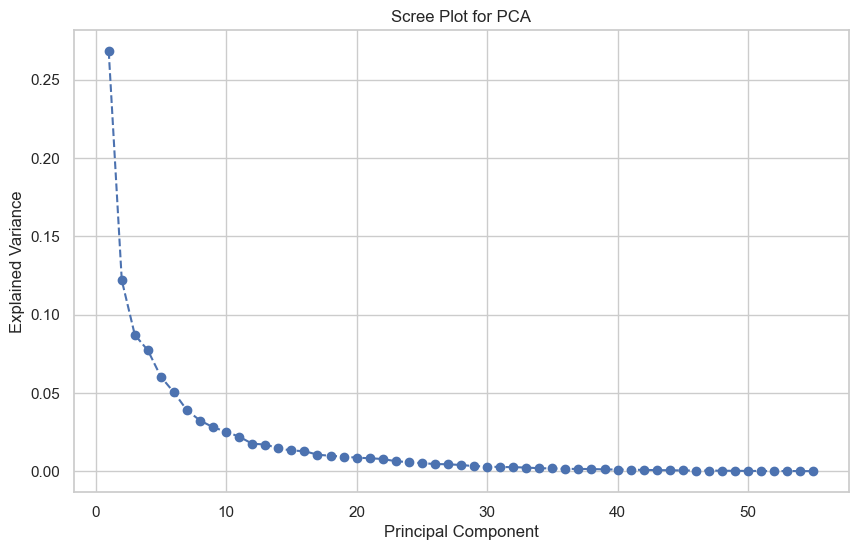

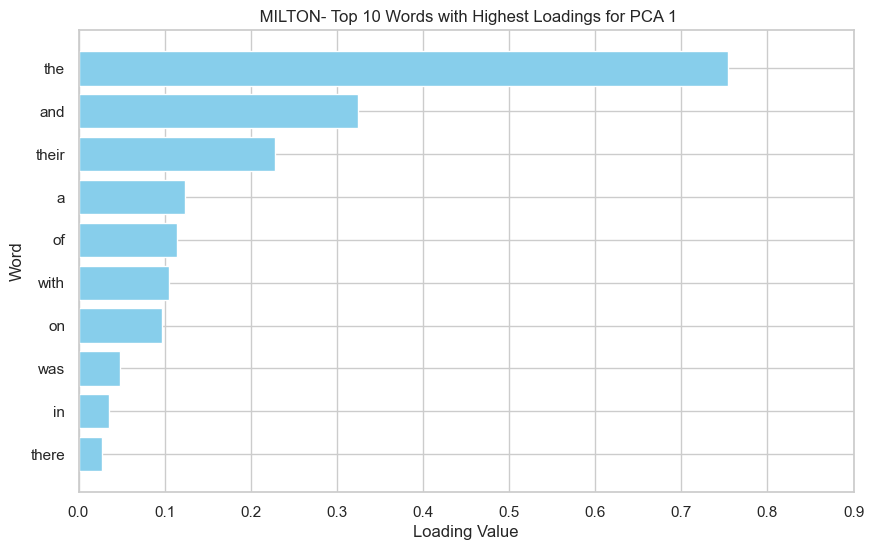

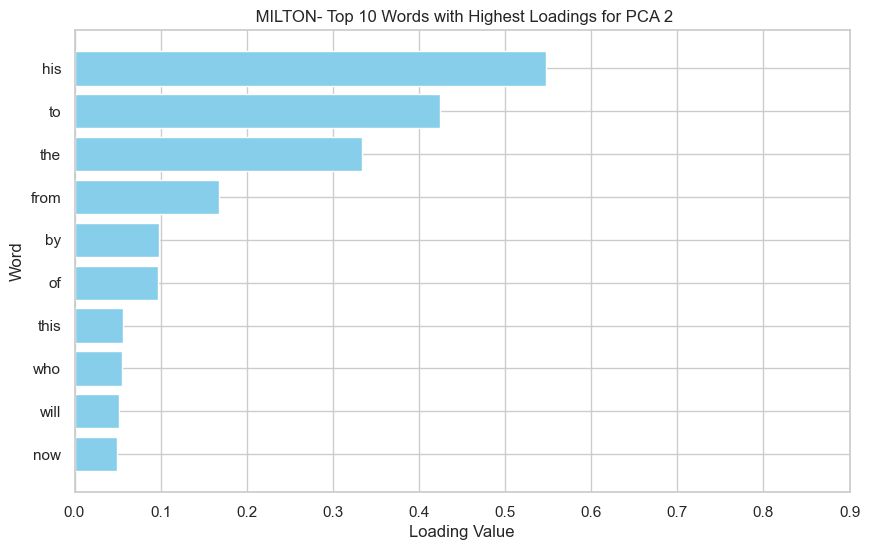

In [119]:
#LONDON
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

london_data = aa[aa['authors'] == 'Milton']
data_for_pca1 = london_data.iloc[:, 0:68]

pca = PCA()
pca_result = pca.fit(data_for_pca1)
explained_variance = pca_result.explained_variance_ratio_

# scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()

#PCA 1
loadings = pca.components_
pca1_loadings = loadings[0]
words = data_for_pca.columns

sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]

# Select the top 10 words 
top_10_words = top_words[:10]
M1=top_10_words

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title(' MILTON- Top 10 Words with Highest Loadings for PCA 1')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()



#PCA 2
loadings = pca.components_
pca1_loadings = loadings[1]
words = data_for_pca.columns

sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]

# Select the top 10 words 
top_10_words = top_words[:10]
M2=top_10_words

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title(' MILTON- Top 10 Words with Highest Loadings for PCA 2')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()



## SHAKESPEARE

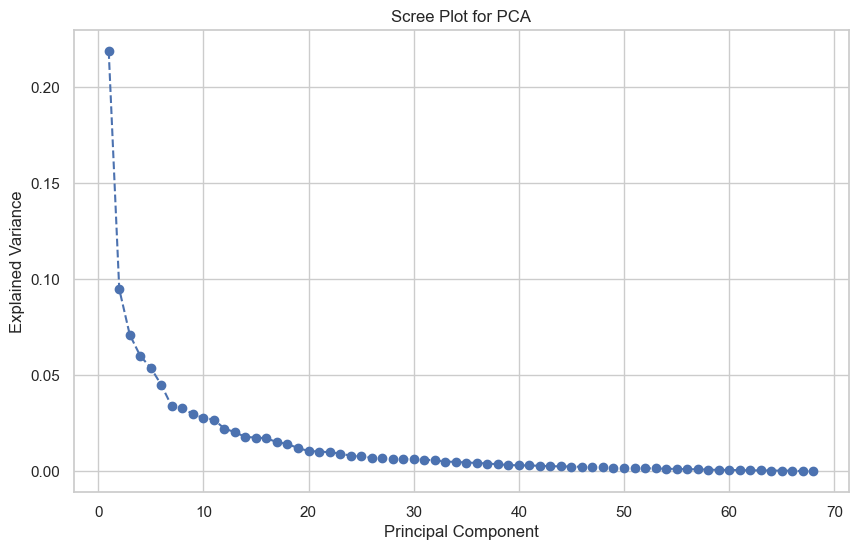

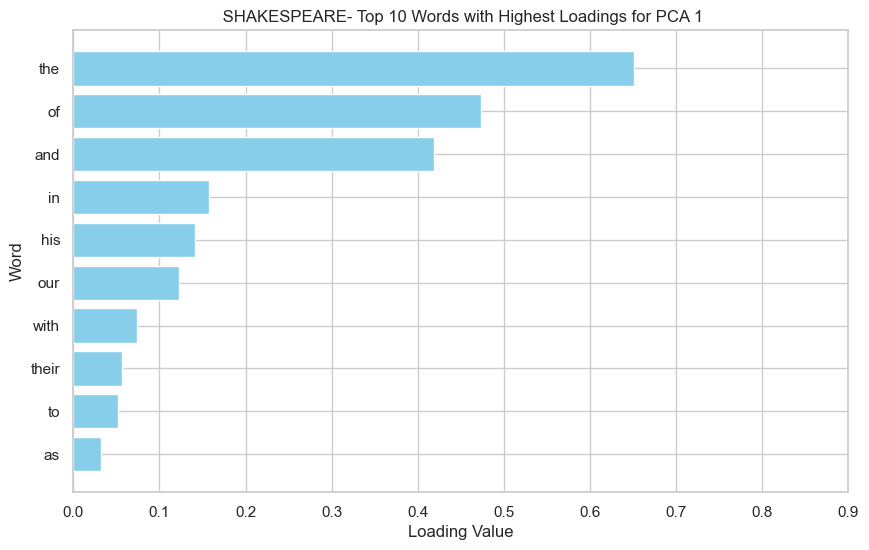

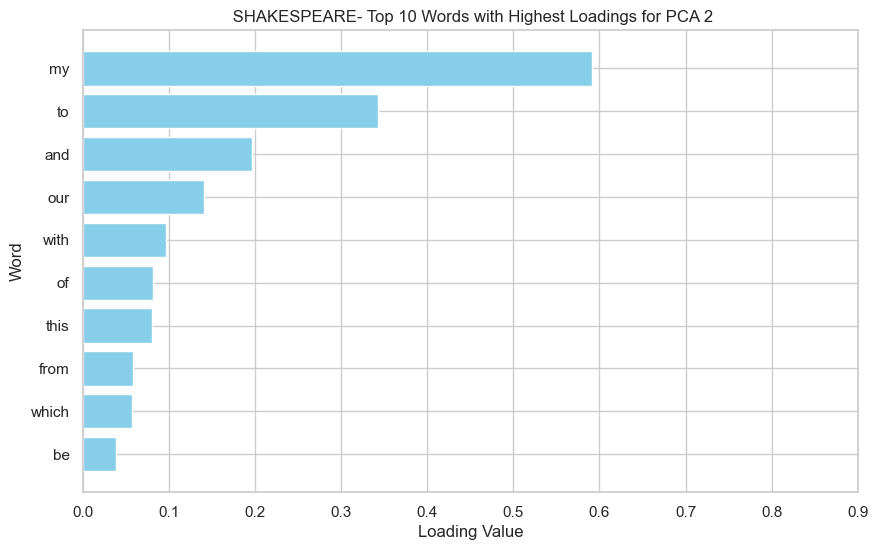

In [120]:
#SHAKESPEARE
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

london_data = aa[aa['authors'] == 'Shakespeare']
data_for_pca1 = london_data.iloc[:, 0:68]

pca = PCA()
pca_result = pca.fit(data_for_pca1)
explained_variance = pca_result.explained_variance_ratio_

# scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot for PCA')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()



#PCA 1
loadings = pca.components_
pca1_loadings = loadings[0]
words = data_for_pca.columns

sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]

# Select the top 10 words 
top_10_words = top_words[:10]
S1=top_10_words

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title(' SHAKESPEARE- Top 10 Words with Highest Loadings for PCA 1')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()



#PCA 2
loadings = pca.components_
pca1_loadings = loadings[1]
words = data_for_pca.columns

sorted_indices = pca1_loadings.argsort()[::-1]
pca1_loadings = pca1_loadings[sorted_indices]
top_words = [words[i] for i in sorted_indices]

# Select the top 10 words 
top_10_words = top_words[:10]
S2=top_10_words

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_words, pca1_loadings[:10], color='skyblue')
plt.title(' SHAKESPEARE- Top 10 Words with Highest Loadings for PCA 2')
plt.xlabel('Loading Value')
plt.ylabel('Word')
plt.gca().invert_yaxis() 
plt.xlim(0, 0.9)
plt.show()



In [132]:
set_A1 = set(A1)
set_A2 = set(A2)
set_L1 = set(L1)
set_L2 = set(L2)
set_L3 = set(L3)
set_M1 = set(M1)
set_M2 = set(M2)
set_S1 = set(S1)
set_S2 = set(S2)
union_of_words = set_A1.union(set_A2, set_L1, set_L2, set_L3, set_M1, set_M2, set_S1, set_S2)
union_list = list(union_of_words)
print(union_list)

['up', 'had', 'with', 'which', 'who', 'that', 'from', 'be', 'no', 'is', 'was', 'their', 'to', 'in', 'its', 'as', 'now', 'were', 'this', 'of', 'his', 'by', 'there', 'for', 'can', 'her', 'the', 'down', 'are', 'will', 'an', 'and', 'been', 'our', 'my', 'on', 'a', 'have']


In [131]:
from IPython.display import HTML
data = {
    'Name of Data': [
        'Austen PCA1', 'Austen PCA2',
        'London PCA1', 'London PCA2', 'London PCA3',
        'Milton PCA1', 'Milton PCA2',
        'Shakespeare PCA1', 'Shakespeare PCA3','Union'],
    'Words': [A1, A2, L1, L2, L3, M1, M2, S1, S2, union_list]}
table_df = pd.DataFrame(data)
table_html = table_df.to_html(index=False, escape=False, classes='table table-bordered', table_id='author-pca-table')
HTML(table_html)

Name of Data,Words
Austen PCA1,"[the, her, of, and, was, had, in, his, were, which]"
Austen PCA2,"[her, to, had, was, that, from, been, for, on, as]"
London PCA1,"[the, and, of, was, in, were, by, had, their, his]"
London PCA2,"[the, an, on, a, up, their, no, can, its, down]"
London PCA3,"[of, my, is, that, have, in, are, will, our, be]"
Milton PCA1,"[the, and, their, a, of, with, on, was, in, there]"
Milton PCA2,"[his, to, the, from, by, of, this, who, will, now]"
Shakespeare PCA1,"[the, of, and, in, his, our, with, their, to, as]"
Shakespeare PCA3,"[my, to, and, our, with, of, this, from, which, be]"
Union,"[up, had, with, which, who, that, from, be, no, is, was, their, to, in, its, as, now, were, this, of, his, by, there, for, can, her, the, down, are, will, an, and, been, our, my, on, a, have]"


## REFLECTION

I performed PCA analysis for pattern recognition and to see which sets of words are important for grouping the author texts

I did PCA analysis first without grouping for the authors, but it does not serve the aim very well. So, I performed PCA for each author seperately. 

I did scree plot to see the explained variance for each principal component, and to decide how many principal components to keep. 

For Austen, Milton and Shakespeare, I used components 1 and 2. For London; 1,2,3. 

The table above summarizes the words for each principal component and Author. 

I also took the union of these words, please see the table:

UNION: 
[up, had, with, which, who, that, from, be, no, is, was, their, to, in, its, as, now, were, this, of, his, by, there, for, can, her, the, down, are, will, an, and, been, our, my, on, a, have

## GRAPHICAL MODELS

## Graphical model: Lasso

In [134]:
from sklearn.covariance import GraphicalLasso
import pandas as pd

stop_words_data = aa.iloc[:, :-3]

graphical_lasso = GraphicalLasso(alpha=0.01)  # You can adjust the regularization strength
graphical_lasso.fit(stop_words_data)

precision_matrix = graphical_lasso.precision_
precision_matrix_df = pd.DataFrame(precision_matrix, columns=stop_words_data.columns, index=stop_words_data.columns)


/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/covariance/_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 34.10895631532185, tolerance: 33.07899007059324
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(


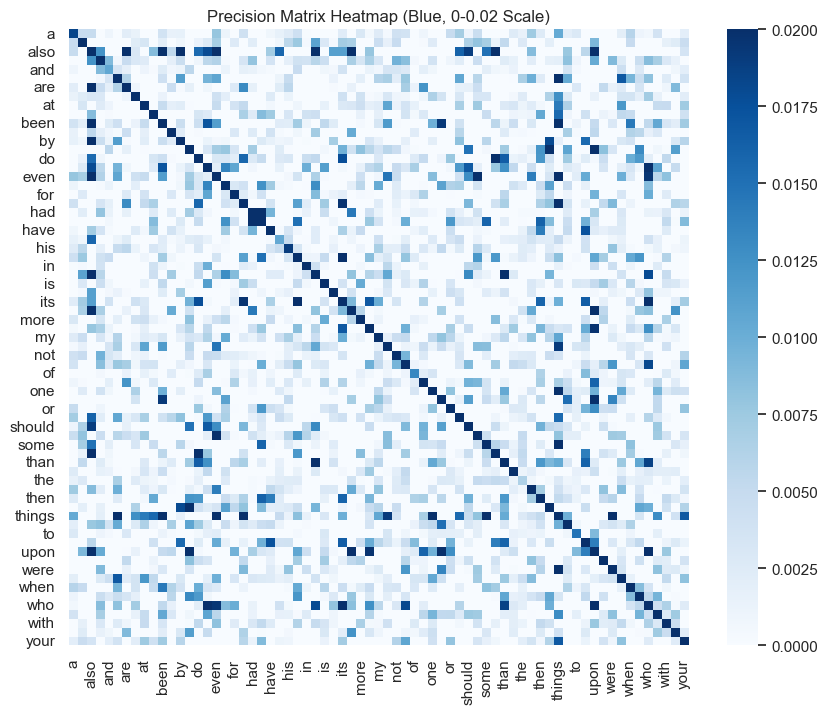

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

vmin = 0
vmax = 0.02

plt.figure(figsize=(10, 8))
sns.heatmap(precision_matrix_df, cmap='Blues', annot=False, vmin=vmin, vmax=vmax)
plt.title('Precision Matrix Heatmap (Blue, 0-0.02 Scale)')
plt.show()


In [142]:
correlation_threshold = 0.02  
#correlated word pairs
correlated_words = []
for i in range(len(precision_matrix_df.columns)):
    for j in range(i + 1, len(precision_matrix_df.columns)):
        if precision_matrix_df.iloc[i, j] > correlation_threshold:
            word1 = precision_matrix_df.columns[i]
            word2 = precision_matrix_df.columns[j]
            correlated_words.append((word1, word2))

for word1, word2 in correlated_words:
    print(f"Correlated words: {word1} and {word2}, Correlation: {precision_matrix_df.loc[word1, word2]}")


Correlated words: also and are, Correlation: 0.0258228193545187
Correlated words: also and been, Correlation: 0.04418741972373901
Correlated words: also and by, Correlation: 0.02221930055011902
Correlated words: also and even, Correlation: 0.04228881818363349
Correlated words: also and into, Correlation: 0.03196942775988171
Correlated words: also and may, Correlation: 0.030190766762310084
Correlated words: also and such, Correlation: 0.0414388867947907
Correlated words: also and upon, Correlation: 0.02659043744202117
Correlated words: any and things, Correlation: 0.025495201566207343
Correlated words: been and things, Correlation: 0.03929977821571242
Correlated words: can and there, Correlation: 0.02133181518882199
Correlated words: can and upon, Correlation: 0.020951397449638212
Correlated words: do and such, Correlation: 0.020686432941848444
Correlated words: down and who, Correlation: 0.028307257059222563
Correlated words: even and so, Correlation: 0.027444635114714705
Correlated wo

## Correlation

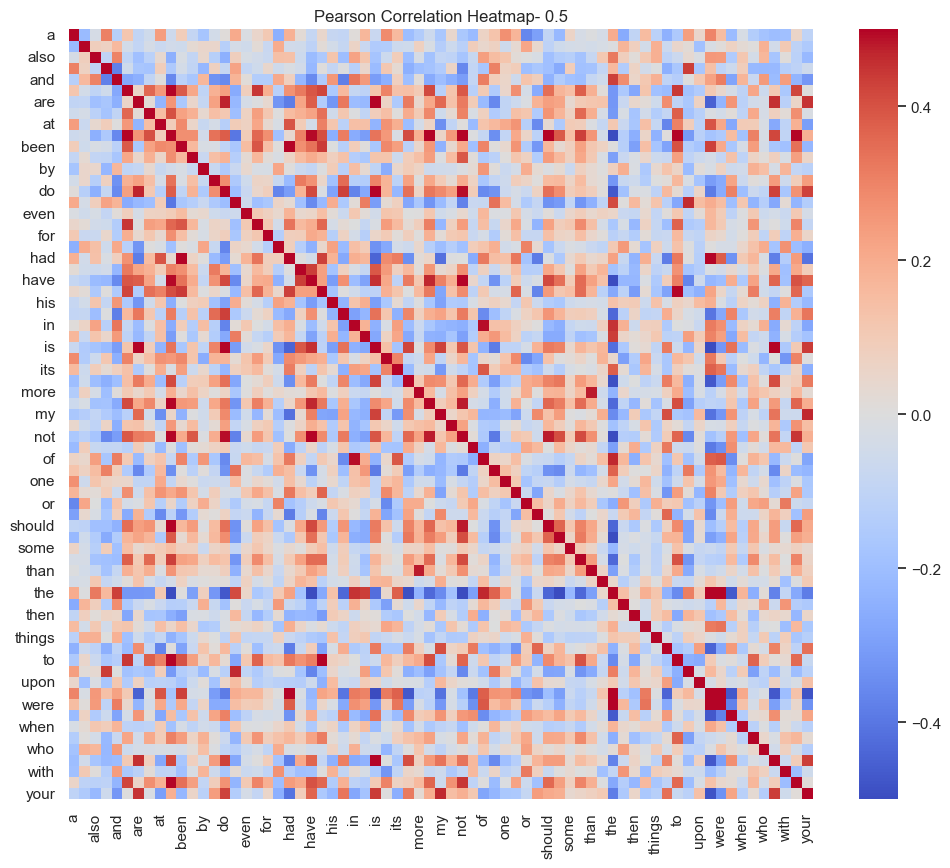

In [144]:
correlation_matrix = aa.iloc[:, :-3].corr()
threshold = 0.5  

import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-0.5, vmax=0.5, annot=False)
plt.title('Pearson Correlation Heatmap- 0.5')
plt.show()

In [147]:
correlated_words = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            correlated_words.add((correlation_matrix.columns[i], correlation_matrix.columns[j]))

print("Correlated words with threshold 0.5=")
for pair in correlated_words:
    word1, word2 = pair
    correlation = correlation_matrix.loc[word1, word2]
    print(f"Correlated words: {word1} and {word2}, Pearson Correlation: {correlation}")


Correlated words with threshold 0.5=
Correlated words: was and had, Pearson Correlation: 0.6715185418597989
Correlated words: was and is, Pearson Correlation: -0.517027547338773
Correlated words: was and the, Pearson Correlation: 0.5377116708060774
Correlated words: were and was, Pearson Correlation: 0.5539852227010172
Correlated words: should and be, Pearson Correlation: 0.5046820097673367
Correlated words: must and be, Pearson Correlation: 0.6091941999083907
Correlated words: had and been, Pearson Correlation: 0.706458420398643
Correlated words: to and be, Pearson Correlation: 0.5044899855238674
Correlated words: not and have, Pearson Correlation: 0.5408825210143705
Correlated words: not and be, Pearson Correlation: 0.5657085849899225
Correlated words: will and is, Pearson Correlation: 0.5034641877695906
Correlated words: the and have, Pearson Correlation: -0.5048598618603868
Correlated words: is and are, Pearson Correlation: 0.617901095830778
Correlated words: the and so, Pearson Co

In [151]:
correlated_words = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        correlation = abs(correlation_matrix.iloc[i, j])
        if 0.02 < correlation < 0.03:
            correlated_words.add((correlation_matrix.columns[i], correlation_matrix.columns[j]))

print("Correlated words with threshold between 0.02 and 0.04:")
for pair in correlated_words:
    word1, word2 = pair
    correlation = correlation_matrix.loc[word1, word2]
    print(f"Correlated words: {word1} and {word2}, Pearson Correlation: {correlation}")


Correlated words with threshold between 0.02 and 0.04:
Correlated words: than and his, Pearson Correlation: -0.027628013861615366
Correlated words: now and by, Pearson Correlation: 0.024044085948008793
Correlated words: would and upon, Pearson Correlation: -0.026948061057842344
Correlated words: such and from, Pearson Correlation: -0.02818521632424756
Correlated words: every and all, Pearson Correlation: 0.020845695435880413
Correlated words: that and into, Pearson Correlation: -0.023387031667611174
Correlated words: there and than, Pearson Correlation: -0.02346598301594839
Correlated words: up and some, Pearson Correlation: -0.025340147154318177
Correlated words: who and this, Pearson Correlation: -0.027964333483323986
Correlated words: things and its, Pearson Correlation: -0.02838748023583463
Correlated words: was and no, Pearson Correlation: -0.024343002844180246
Correlated words: with and but, Pearson Correlation: -0.022391792830048333
Correlated words: had and down, Pearson Correl

## REFLECTION

I used graphical model Lasso and pearson correlation analysis to see the associations between word occurrences.

### Lasso
Lasso is primarily a machine learning and feature selection technique, aiming to to identify a subset of relevant features. This results in smaller correlation coefficients for non-selected features.

As threshold, I picked 0.02 for Lasso, and listed the words that are relevant, greater than threshold value. 


### Pearson correlation analysis 
 Pearson correlation analysis is a statistical method used to quantify relationships. This method calculates correlation coefficients for all word pairs, providing information on relationships. 
 
For pearson correlation I picke 0.5 as threshold and words ar listed above. 

### Compare

The words that are found with pearson correlation and Lasso are different because Lasso focuses on feature selection for predictive modeling, while Pearson correlation focuses on measuring linear associations between variables. 

I also looked at Pearson correlation with the same threshold of lasso, that is 0.02-0.03, and as expected they do not show similar words. 


## CLUSTER VALIDATION

## Cluster validation - Consensus

In [160]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.metrics import adjusted_rand_score

info_cols = aa.columns[-3:]
X = aa.iloc[:, :-3].values  
np.random.seed(10)
K = 4
iterations = 100

n, _ = X.shape
consensus_matrix = np.zeros((n, n))
sampled_matrix = np.zeros((n, n))

for _ in range(iterations):
    train_idx = np.random.choice(n, int(0.7 * n), replace=False)
    X_train = X[train_idx]

    km = KMeans(n_clusters=K, random_state=0).fit(X_train)
    sampled_matrix[np.ix_(train_idx, train_idx)] += 1
    co_members = (km.labels_[:, np.newaxis] == km.labels_).astype(int)
    consensus_matrix[np.ix_(train_idx, train_idx)] += co_members

consensus_matrix /= sampled_matrix



/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change fr

/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change fr

/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change fr

/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change fr

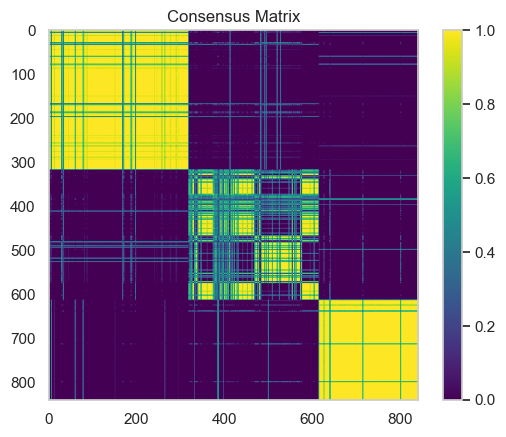

In [161]:
import matplotlib.pyplot as plt

# Visualize the consensus matrix
plt.imshow(consensus_matrix, cmap='viridis', origin='upper')
plt.title("Consensus Matrix")
plt.colorbar()
plt.grid(False)  
plt.show()

## Cluster validation - Data Splitting

In [159]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import adjusted_rand_score
from tabulate import tabulate

np.random.seed(0)

info_cols = aa.columns[-3:]
X = aa.iloc[:, :-3].values

train_idx = np.random.choice(X.shape[0], int(0.7 * X.shape[0]), replace=False)
test_ind= np.setdiff1d(np.arange(X.shape[0]), train_idx)
X_train = X[train_idx]
X_test = X[np.setdiff1d(np.arange(X.shape[0]), train_idx)]

K = 4
km_train = KMeans(n_clusters=K, random_state=0).fit(X_train)
X_train = np.column_stack((X_train, km_train.labels_))

# Train a multinomial logistic regression model with the clusters as labels
classifier = LogisticRegression(multi_class='multinomial', solver='lbfgs')
classifier.fit(X_train[:, :-1], X_train[:, -1])

# Cluster X_test
km_test = KMeans(n_clusters=K, random_state=0).fit(X_test)

# Predict the labels
preds = classifier.predict(X_test)


# Compute the Adjusted Rand Index (ARI)
ari = adjusted_rand_score(km_test.labels_, preds)
print("ARI:", ari)

# DataFrame with the cluster labels and authors for the test data
authors_test = aa.iloc[test_ind, 69].values
km_test= km_test.labels_
test_data = pd.DataFrame({'Cluster': km_test, 'Author': authors_test})

# contingency table
contingency_table = pd.crosstab(test_data['Cluster'], test_data['Author'], rownames=['Cluster'], colnames=['Author'])
print(tabulate(contingency_table, headers='keys', tablefmt='fancy_grid'))


/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


ARI: 0.9040573273340129
╒═══════════╤══════════╤══════════╤══════════╤═══════════════╕
│   Cluster │   Austen │   London │   Milton │   Shakespeare │
╞═══════════╪══════════╪══════════╪══════════╪═══════════════╡
│         0 │        1 │       31 │        1 │             0 │
├───────────┼──────────┼──────────┼──────────┼───────────────┤
│         1 │        1 │       48 │        1 │             0 │
├───────────┼──────────┼──────────┼──────────┼───────────────┤
│         2 │      103 │        1 │        0 │             0 │
├───────────┼──────────┼──────────┼──────────┼───────────────┤
│         3 │        1 │        1 │       11 │            53 │
╘═══════════╧══════════╧══════════╧══════════╧═══════════════╛


/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


## REFLECTION

I performed cluster validation by using concensus matrix and data splitting.

### Consensus

Consensus matrix shows two big clusters at the corners very clearly. 

In the middle, I see 2 or 3 clsuters at the diagonal, two of them are bigger but kind of leaks to other clusters. There is one small cluster that is seen more distinct.  

If we look at the diagonal we see 5 clusters, although we have 4 authors. 

The matrix is not too messy, but the problem seems to lie between two of the 5 clusters. Those probably belongs to same author.

### Data Splitting 

Looking at the contingency table: Shakespeare and Austen seems like clustered seperately. Comparing with the consensus, they must be the big squares at the corners. 

At the contingency table I see Milton is classified clearly, that must be the little distinct cluster at the diagonal of the consensus matrix. 

The contingency table shows London to form in two seperate cluster almost equally. That must be the two middle clusters in the consensus matrix.  

The ARI score is 0.90, whic is a good score for classifying. 

### Summary

The data splitting and the ARI score align with the consensus table. 

I can tell this classification is succesful mostly but can't identify London very well. 